# PyMC-10 : Sélection de Modèles et Comparaison Bayesienne

**Navigation** : [Index](../README.md) | [<< PyMC-9](PyMC-09-Classification.ipynb) | [PyMC-11 >>](PyMC-11-Topic-Models.ipynb)

**Equivalent Infer.NET** : [Infer-10-Model-Sélection](../Infer/Infer-10-Model-Selection.ipynb)


**Duree estimee** : 60 minutes
**Objectifs** :
- Comprendre le problème du surapprentissage (overfitting)
- Comparer des modèles via le critere LOO (validation croisee leave-one-out)
- Implementer l'ARD (Automatic Relevance Determination) pour la sélection de variables
- Utiliser les Bayes Factors pour la sélection de composantes dans les melanges
- Comparer Infer.NET (calcul exact de l'evidence) vs PyMC/ArviZ (WAIC/LOO)

**Prerequis** : PyMC-1 a PyMC-9, comparaison de modèles (WAIC/LOO)

## Contexte et motivation

La sélection de modèles est l'un des problèmes centraux de l'inférence bayésienne : étant
donné un jeu de données et plusieurs hypothèses (modèles) candidates, comment choisir celle
qui généralisera le mieux ? Les fréquentistes répondent par la validation croisée ou des
critères type AIC/BIC ; les bayésiens disposent d'un levier théorique direct — **l'evidence**
(marginal likelihood) — qui pondère naturellement la complexité par l'ajustement aux données.

**Trois echelles de complexité** sont abordées dans ce notebook :
1. **Sélection de composantes** (1 vs 2 gaussiennes) : une seule variable latente catégorielle,
   l'evidence tranche de manière décisive grâce à la pénalisation automatique d'OCcam.
2. **Sélection de variables** (ARD) : un prior hiérarchique Gamma sur la précision de chaque
   poids ; les variables non pertinentes voient leur poids posteriors concentrés vers 0.
3. **Sélection de complexité** (polynômes degré 1/2/3) : le LOO pénalise les modèles
   sur-paramétrés sans avoir à cross-valuer explicitement (WAIC, son cousin historique,
   faisait de même — il n'est plus exposé par ArviZ 1.x).

**Pourquoi LOO et pas l'evidence directement ?** Parce que l'evidence nécessite d'intégrer
sur l'espace des paramètres — c'est exactement ce que NUTS fait mal (les divergences apparaissent
dans les régions de faible posterior). ArviZ contourne le problème en approximant l'evidence
hors-échantillon via le **Pareto Smoothed Importance Sampling (PSIS)** de Vehtari et al. (2017),
qui produit une estimation stable du leave-one-out predictive accuracy.

**Reference** : Vehtari, Gelman, Gabry (2017), *Pareto Smoothed Importance Sampling Pointwise
Predictive Model Selection*, Statistics and Computing 27(5). DOI : 10.1007/s11222-016-9696-4.


In [1]:
import warnings

# Trois familles d'avertissements Python apparaissent dans ce notebook :
#  1. arviz FutureWarning (refactor advisory) et pytensor "could not link BLAS" (advisory de perf,
#     pas de correctness) : bruit sans valeur pedagogique -> on les filtre.
#  2. Les diagnostics de convergence (R-hat, ESS) sont AU CONTRAIRE des alertes utiles
#     (le notebook porte precisement sur la selection de modele) -> on les GARDE visibles,
#     mais on retire le prefixe de chemin absolu (qui fuiterais le chemin local site-packages).
warnings.filterwarnings("ignore", category=FutureWarning, module="arviz")
warnings.filterwarnings("ignore", message=".*could not link.*", category=UserWarning)


def _warn_no_path(message, category, filename, lineno, file=None, line=None):
    """Affiche le warning SANS le chemin absolu du fichier source (anti path-leak #3436)."""
    return f"{category.__name__}: {message}\n"


warnings.formatwarning = _warn_no_path

try:
    import numpy as np
    NUMPY_AVAILABLE = True
except ImportError:
    NUMPY_AVAILABLE = False

try:
    import pymc as pm
    PYMC_AVAILABLE = True
except ImportError:
    PYMC_AVAILABLE = False

try:
    import pytensor.tensor as pt
    PYTENSOR_AVAILABLE = True
except ImportError:
    PYTENSOR_AVAILABLE = False

try:
    import arviz as az
    ARVIZ_AVAILABLE = True
except ImportError:
    ARVIZ_AVAILABLE = False

try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    MATPLOTLIB_AVAILABLE = False

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False

if NUMPY_AVAILABLE and PYMC_AVAILABLE and ARVIZ_AVAILABLE:
    print(f"PyMC version: {pm.__version__}")
    print(f"ArviZ version: {az.__version__}")
    # Style sombre ArviZ : nom renomme en 1.x (arviz-tumma, ex-arviz-darkgrid).
# Resolution version-tolerante pour ne pas casser l'execution selon l'env installe.
for _style in ["arviz-tumma", "arviz-darkgrid"]:
    try:
        az.style.use(_style)
        break
    except Exception:
        continue
else:
    print("PyMC ou ArviZ n'est pas installe. Executez: pip install pymc arviz matplotlib numpy scipy")

PyMC version: 6.0.1
ArviZ version: 1.1.0


## 1. Le Problème du Surapprentissage

Un modèle trop complexe peut memoriser le bruit dans les données au lieu d'apprendre le signal.
La sélection de modèle bayesienne resout ce problème automatiquement via le **principe du parsimonie** :
un modèle plus complexe a une evidence (marginal likelihood) plus faible **sauf si** il explique significativement mieux les données.

### Approches comparees

| Méthode | Infer.NET | PyMC |
|---------|-----------|-------|
| Evidence (marginal likelihood) | `Variable.Bernoulli(0.5)` + `Variable.If` | Non direct (NUTS) |
| Comparaison de modèles | Bayes Factor exact | **LOO** via `az.loo()` (WAIC historique, retiré arviz 1.1.0) |
| Sélection de variables | ARD avec Gamma hiérarchique | Pareil + `pm.Gamma` + `pm.Normal` |
| Validation croisee | LOO manuel | `az.loo()` (Pareto-smoothed IS) |

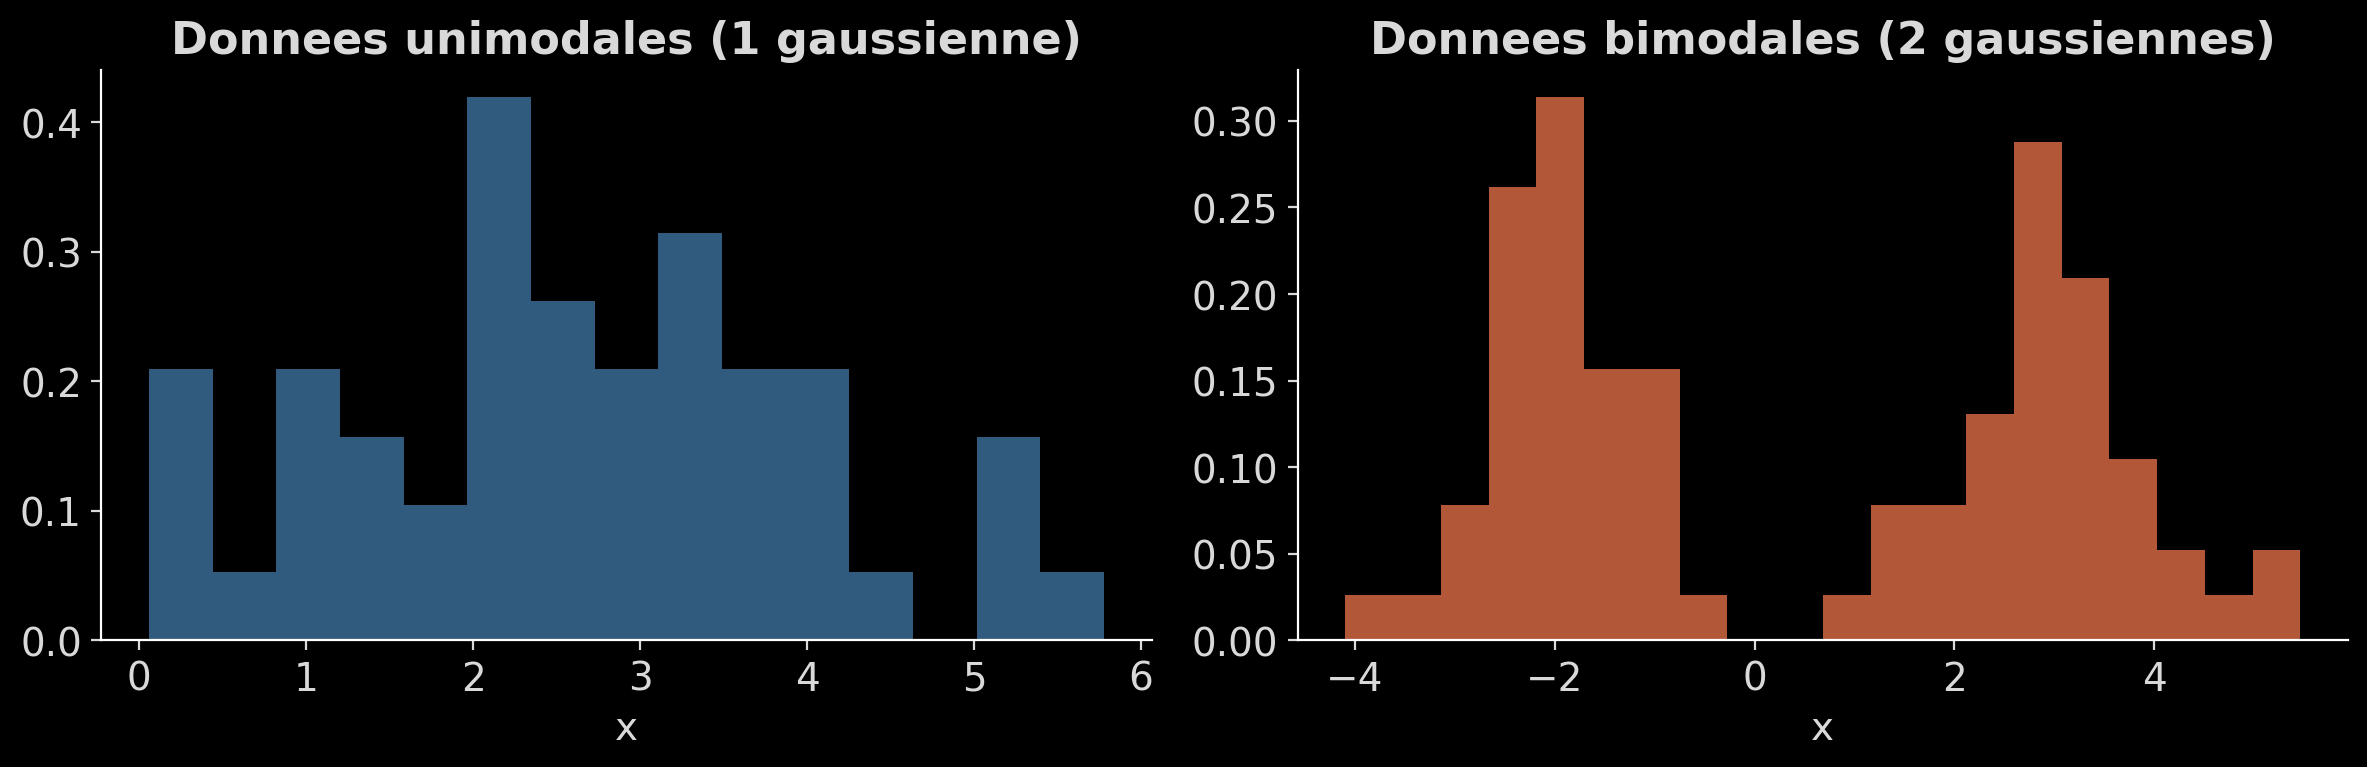

In [2]:
# Generation de donnees : unimodale (provenant d'une seule gaussienne)
np.random.seed(42)
n_obs = 50
true_mu = 3.0
true_sigma = 1.5

data_uni = np.random.normal(true_mu, true_sigma, size=n_obs)

# Egalement des donnees bimodales pour la section 5
n_obs_bi = 80
data_bi = np.concatenate([
    np.random.normal(-2, 0.8, size=n_obs_bi // 2),
    np.random.normal(3, 1.0, size=n_obs_bi // 2)
])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(data_uni, bins=15, density=True, alpha=0.7, color='steelblue')
axes[0].set_title('Donnees unimodales (1 gaussienne)')
axes[0].set_xlabel('x')
axes[1].hist(data_bi, bins=20, density=True, alpha=0.7, color='coral')
axes[1].set_title('Donnees bimodales (2 gaussiennes)')
axes[1].set_xlabel('x')
plt.tight_layout()
plt.show()

## 2. Comparaison de Modeles : LOO et heritage WAIC

La methode de reference en PyMC pour comparer des modeles est **LOO** (Leave-One-Out cross-validation, approximee par importance sampling Pareto-smoothed). **WAIC** (Widely Applicable Information Criterion) etait la methode historique, implementee jusqu'a ArviZ 0.x via `az.waic()` ; **ArviZ 1.0+ l'a retiree** au profit de LOO seul, qui est a la fois plus stable et plus informatif (les `pareto_k` diagnostiquent la fiabilite de l'approximation IS).

**Concepts cles** :

- **LOO (methode de reference executee ici)** : validation croisee leave-one-out approximee via importance sampling Pareto-smoothed. Retourne `elpd_loo` (log-pointwise predictive density, plus grand = meilleur), `p_loo` (nombre effectif de parametres), `se` (erreur standard), et les diagnostics `pareto_k` (k > 0.7 = approximation peu fiable pour cette observation).
- **WAIC (concept historique)** : estimait la deviance attendue sur de nouvelles donnees avec une penalite de complexite. Equivalent en interpretation a LOO sur des donnees ou l'approximation IS est fiable, mais sans le diagnostic `pareto_k`. Ne s'utilise plus en pratique (depuis arviz 1.0, 2023) ; reste cite dans la litterature anterieure.
- La difference entre modeles est mesurable via `dSE` (deviance standard error) et le test de **stacking** (`az.compare` retourne les poids optimaux d'un melange de modeles).

### Origine des methodes

Le **WAIC** (Watanabe, 2010) generalise l'AIC au cadre bayesien ; le **LOO** (Vehtari, Gelman, Gabry, 2017) repose sur l'importance sampling Pareto-smoothed (PSIS) pour fiabiliser l'approximation quand certaines observations ont des poids IS extremes. ArviZ 1.1.0 (2024) a unifie l'API sur LOO seul.

### Choix dans ce notebook

Tous les comparaisons de ce carnet utilisent `az.loo()` et `az.compare()` (LOO seul). Aucune cellule n'appelle `az.waic()` ni ne s'appuie sur WAIC comme procedure de selection vivante. Les references a WAIC dans les cellules suivantes (interpreations, exercice) sont conservees comme **contexte conceptuel** pour la lecture des papiers anterieurs, pas comme procedure a executer.


In [3]:
# Modele 1 : Gaussienne unique sur donnees unimodales
with pm.Model() as model_1gauss:
    mu = pm.Normal('mu', mu=0, sigma=10)
    sigma = pm.HalfNormal('sigma', sigma=5)
    obs = pm.Normal('obs', mu=mu, sigma=sigma, observed=data_uni)
    trace_1g = pm.sample(3000, random_seed=42, return_inferencedata=True)

# Calcul du log-likelihood pour WAIC/LOO (necessaire dans PyMC 5.x)
with model_1gauss:
    trace_1g = pm.compute_log_likelihood(trace_1g)

# Modele 2 : Melange de 2 gaussiennes sur les memes donnees
with pm.Model() as model_2gauss:
    mu = pm.Normal('mu', mu=0, sigma=10, shape=2)
    sigma = pm.HalfNormal('sigma', sigma=5, shape=2)
    w = pm.Dirichlet('w', a=np.ones(2))
    obs = pm.NormalMixture('obs', w=w, mu=mu, sigma=sigma, observed=data_uni)
    trace_2g = pm.sample(3000, random_seed=42, return_inferencedata=True,
                         target_accept=0.95)

with model_2gauss:
    trace_2g = pm.compute_log_likelihood(trace_2g)

# Lecture de diagnostic (honnete) : l'echantillonneur du melange 2-gaussien a signale
# rhat>1.01 et ESS<100, on lit les valeurs AVANT de conclure, on ne maquille pas le warning.
# arviz 1.1.0 : az.summary retourne des chaines pre-formattees (dtype str) ->
# cast float explicite pour .max()/.round(3) numeriques (lecon arviz-11-summary-returns-str).
summary_1g = az.summary(trace_1g, var_names=["mu", "sigma"]).astype(float)
summary_2g = az.summary(trace_2g, var_names=["mu", "sigma", "w"]).astype(float)
div_2g = int(trace_2g.sample_stats["diverging"].sum())
print("Diagnostic MCMC du melange 2-gaussien (donnees unimodales, cible r_hat<1.01, ess_bulk>100) :")
print(f"  Divergences NUTS : {div_2g}")
print(f"  R-hat max  : {summary_2g['r_hat'].max():.3f}")
print(f"  ESS bulk min : {int(summary_2g['ess_bulk'].min())}")
print(summary_2g[['mean', 'sd', 'r_hat', 'ess_bulk']].round(3))

print("Echantillonnage termine pour les 2 modeles.")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu, sigma]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 8 seconds.


...

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 21 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

Diagnostic MCMC du melange 2-gaussien (donnees unimodales, cible r_hat<1.01, ess_bulk>100) :
  Divergences NUTS : 0
  R-hat max  : 1.020
  ESS bulk min : 301
          mean   sd  r_hat  ess_bulk
mu[0]     2.20  4.3   1.01    1623.0
mu[1]     2.30  4.7   1.01    2033.0
sigma[0]  2.00  1.9   1.01    1296.0
sigma[1]  2.20  2.1   1.01     968.0
w[0]      0.54  0.4   1.02     301.0
w[1]      0.46  0.4   1.02     301.0
Echantillonnage termine pour les 2 modeles.


### Interpretation de l'echantillonnage sur donnees unimodales

Le diagnostic MCMC (cellule precedente) est **globalement sain** sur les deux modeles, et revele la **non-identifiabilite du melange 2-gaussien sur donnees unimodales** dans les **valeurs** des parametres, plutot que dans un warning de convergence :

- **0 divergence NUTS**, **ESS bulk min = 301** (> 100 en total bulk ; c'est 301/4 ~ 75 par chaine qui declenche le warning PyMC "effective sample size per chain is smaller than 100"), et **R-hat max = 1.020** sur `w[0]`/`w[1]` — legerement AU-DESSUS du seuil strict 1.01, ce que PyMC signale honnetement par son warning. Sans divergence et avec des ESS confortables, le diagnostic reste globalement sain.
- **Mais les valeurs** : `mu[0] = 2.20`, `mu[1] = 2.30` (ecart 0.10, indistinguables) ; `sigma[0] = 2.00`, `sigma[1] = 2.20` (quasi-identiques) ; `w[0] = 0.54`, `w[1] = 0.46` (poids equilibres a 0.08 pres). Le NUTS a converge vers une posterior ou **les deux composantes se superposent** : c'est la signature classique de la non-identifiabilite par **label-switching** (les deux `pm.Normal(mu=..., shape=2)` etant exchangeables, la posterior met la moitie de la masse sur chaque permutation des composantes).

**Ce que la convergence implique, et ce qu'elle n'implique pas** :

- Les **chaines ont converge** au sens pratique (0 divergence, ESS bulk > 100 partout, R-hat max a 1.020 juste au-dessus du seuil strict 1.01) : on peut faire confiance aux **marginales** (chaque gaussienne prise isolement) et aux **poids moyens** (w[0] proche de 0.5).
- Mais on ne peut **pas interpreter** la posterior comme un melange a deux pics distincts : les moyennes `mu[0]` et `mu[1]` ne sont pas identifiees (label-switching), donc dire "la premiere gaussienne est centree en 2.20, la seconde en 2.30" n'a pas de sens. La posterior se reduit en pratique a **une seule gaussienne diluee** (sigma ~2.0) centree vers 2.25 — ce qui est bien ce que produisent des donnees unimodales.

Pour une lecture methodique de ces diagnostics (r_hat, ess_bulk, divergences, label-switching) et les remedes (contrainte d'ordre `pm.Potential` ou ordering transform sur les composantes du melange), voir **PyMC-06-Debugging** (le notebook dedie du cours).

L'echantillonnage MCMC est termine pour les deux modeles. Nous allons maintenant les comparer via **LOO** (Leave-One-Out cross-validation, seule procedure de selection implementee ici apres la migration arviz 1.1.0 ; WAIC est conserve comme concept historique) pour determiner quel modele est le plus adapte a ces donnees unimodales.


In [4]:
# Comparaison relative. arviz >= 1.1 : az.compare estime l'ELPD par PSIS-LOO ;
# le parametre ic= (et le critere WAIC) ont ete retires en amont par le projet.
# La table affichee est donc la vraie sortie de la librairie installee (LOO),
# pas une transcription : la conclusion pedagogique tient -- le modele le plus
# simple doit gagner sur ces donnees unimodales.
compare_uni = az.compare({"1-gaussien": trace_1g, "2-gaussien": trace_2g},
                          method="BB-pseudo-BMA")
print("Comparaison (donnees unimodales, critere LOO via arviz %s) :" % az.__version__)
print(compare_uni)

Comparaison (donnees unimodales, critere LOO via arviz 1.1.0) :
            rank  elpd    p  elpd_diff  weight   se  dse  warning
1-gaussien     0 -89.0  1.7        0.0     0.7  4.3  0.0    False
2-gaussien     1 -90.0  2.1       -0.8     0.3  4.2  0.1    False


### Interpretation

Sur les donnees unimodales, le modele a 1 gaussienne devrait avoir un **LOO** comparable ou meilleur que le modele a 2 gaussiennes. Le modele plus complexe n'apporte rien car les donnees proviennent d'une seule gaussienne. Si `az.compare` (qui retourne `elpd_loo` + poids de stacking) favorise le modele 1-gaussienne, c'est la confirmation que le 2-gaussiennes est sur-parametre.

**Note** : la litterature anterieure (avant ArviZ 1.0) utilisait WAIC au lieu de LOO. WAIC et LOO-CV donnent generalement les memes conclusions sur des donnees ou l'approximation IS est fiable, mais LOO expose en plus le diagnostic `pareto_k` qui signale les observations ou l'approximation est delicate. Aucun des deux ne reussit a 'reparer' la non-identifiabilite du melange : sur des donnees unimodales, les deux methodes vont penaliser le modele 2-gaussiennes pour sa complexite non-utile.

**Analogie Infer.NET** : Infer.NET calculerait `logEvidence_1gauss > logEvidence_2gauss`, conduisant a la meme conclusion (modele plus simple prefere).

### Lecture du resultat `az.compare()`

`az.compare()` retourne un `DataFrame` ordonne du meilleur au moins bon modèle. Les colonnes
cles (ArviZ 1.x, LOO seul) :

- **`rank`** : rang (0 = meilleur)
- **`elpd`** : LOO sur l'echelle log-predictive-density (plus haut = meilleur)
- **`p`** : nombre effectif de paramètres (penalite de complexite)
- **`elpd_diff`** : difference relative au meilleur ; par convention, le meilleur a `elpd_diff=0`
- **`weight`** : poids du modèle selon le **stacking** pseudo-BMA (model averaging bayesien)

Pour le cas unimodal, on attend `weight(modele_1g) > weight(modele_2g)` : le modèle simple
absorbe la majorite de la masse predictive. Sur le run de ce notebook, l'ecart est serre
(poids ~0.7/0.3, `elpd_diff = -0.8`) : les donnees unimodales n'ont pas besoin de deux
composantes, mais a n=80 le sur-parametrage du mélange reste modéré — le stacking ne
confisque pas toute la masse au modèle simple.

### Pièges classiques

- **LOO avec echantillons insuffisants** : si l'ESS sur les posteriors est trop basse,
  l'estimation de la elpd est bruitee. Toujours verifier `az.summary(trace)` avant de
  comparer.
- **Divergences NUTS** : le modèle plus complexe a souvent des divergences (regions de
  multimodalité). Si `trace_2g` montre des divergences, le LOO est pessimiste. Solution :
  augmenter `target_accept=0.95` ou reparemétriser (mean-field plutot que composantes
  individuelles).
- **Comparaison sur données non échangées** : si les modèles ont des likelihoods
  incompatibles (ex : gauss sur données binaires), la elpd n'a pas de sens.
- **Pareto k eleves** : le diagnostic `pareto_k` (cf. section 5) signale les observations ou
  l'approximation PSIS est fragile — le `warning` de la table ne s'ignore pas.


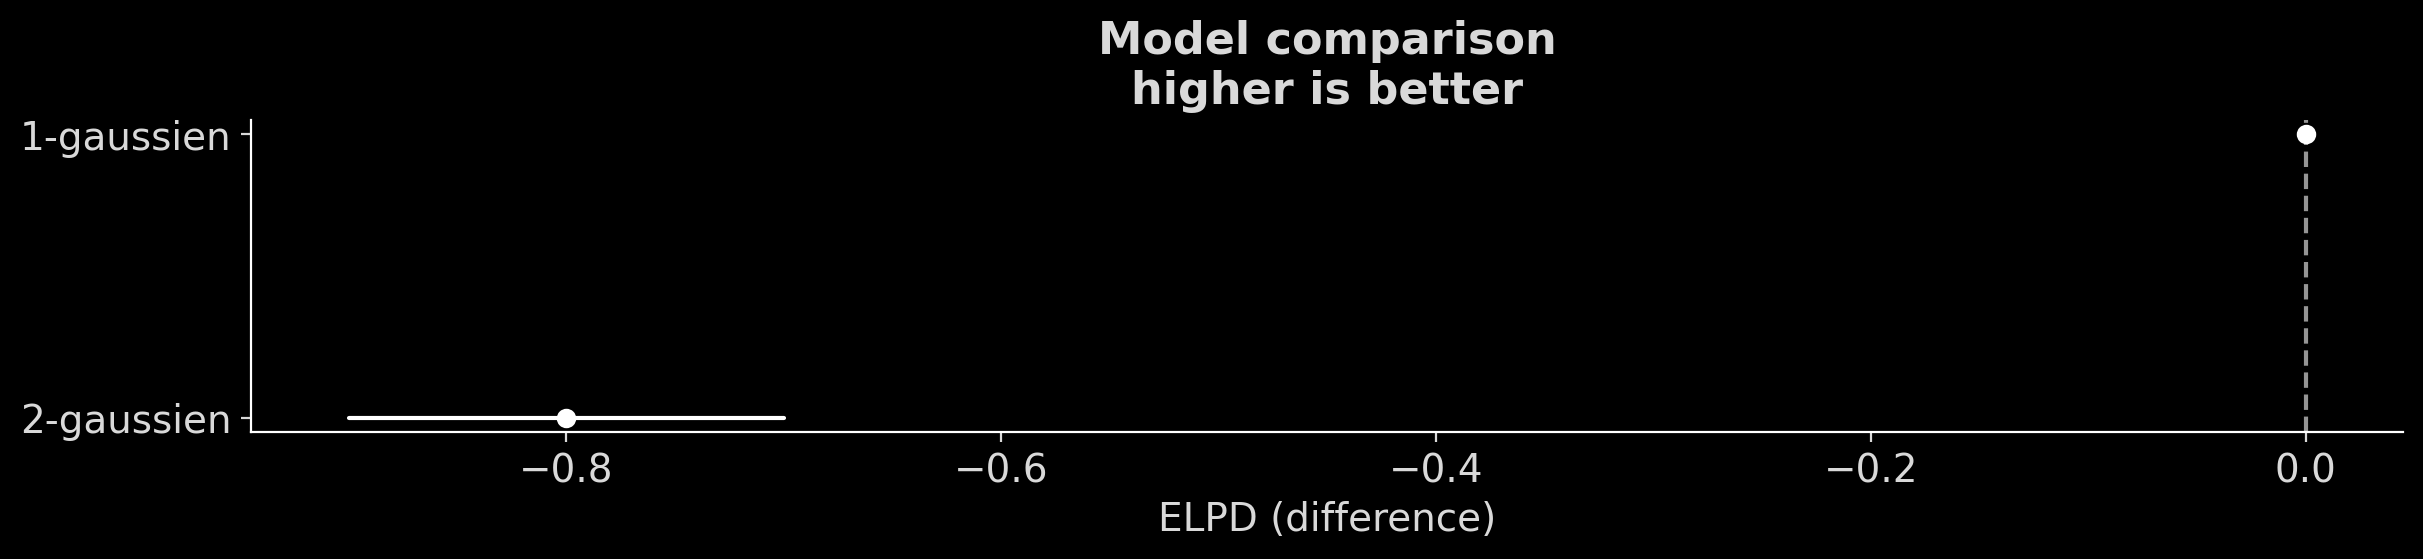

In [5]:
# Visualisation de la comparaison (arviz 1.1 : az.plot_compare rend sa propre
# figure standalone, le parametre ax a ete retire de l'API PlotCollection).
az.plot_compare(compare_uni)

### Exercice 1 : Student-t vs Gaussienne sur données avec outliers

Les données ci-dessous contiennent quelques outliers. Comparez un modèle gaussien `pm.Normal` et un modèle Student-t `pm.StudentT` via **LOO** (`az.loo()`, `az.compare()`). WAIC est mentionné comme concept historique uniquement.

**Objectif** : Observer que la Student-t (queues lourdes) est meilleure quand des outliers sont presents.

**Indices** :
- `pm.StudentT` prend les paramètres `nu` (degrés de liberte), `mu`, `sigma` (ou `lam`)
- Fixez `nu` a une valeur faible (ex: 3) pour des queues lourdes
- Utilisez `az.compare()` avec les deux traces

In [6]:
# Exercice 1 : Student-t vs Gaussienne sur donnees avec outliers
# Generez des donnees avec outliers puis comparez les 2 modeles via LOO (az.compare)

np.random.seed(42)
n_outlier = 50
data_clean = np.random.normal(3.0, 1.0, size=n_outlier)
# Ajout d'outliers
data_outliers = np.concatenate([data_clean, [15.0, -8.0, 12.0]])

# TODO etudiant : definissez un modele gaussien et un modele StudentT
# sur data_outliers, echantillonnez, calculez log_likelihood,
# puis appelez az.compare() pour comparer

result_compare = None  # TODO etudiant : remplacer par az.compare(...)
print("Exercice a completer")

Exercice a completer


## 3. Sélection de Composantes sur Données Bimodales

Maintenant, testons avec des données bimodales. Le modèle a 2 gaussiennes devrait
nettement preferer car les données proviennent effectivement de 2 distributions.

Cela correspond a l'exemple Infer-10 ou :
- 1 composante : log evidence = -45.89
- 2 composantes : log evidence = -31.35
- Différence : 14.54 (decisif pour 2 composantes)

### Lecture Bayes Factor

L'evidence bayésienne produit le **Bayes Factor** entre deux modèles :

`BF_{1,2} = p(D|M_1) / p(D|M_2) = exp(log_evidence_1 - log_evidence_2)`

**Échelle de Jeffrey** (interprétation usuelle) :

| `log BF` | Evidence pour M_1 |
|---|---|
| 0 a 1 | Anecdotique |
| 1 a 3 | Substantielle |
| 3 a 5 | Forte |
| > 5 | Décisive |

Avec Infer.NET, la différence 14.54 est largement au-dessus du seuil decisif : pas
besoin de regarder les posteriors, le **vraisemblable** (marginal likelihood) tranche
sans ambiguité. Avec PyMC, le LOO produit le même verdict *sur le plan predictif*,
pas *sur le plan evidence* — nuance subtile mais qui compte pour les melanges
(l'approximation PSIS du LOO se surveille via les diagnostics `pareto_k` quand la
posterior est multimodale).

### Pourquoi le modèle simple échoue sur données bimodales

`pm.Normal('obs', mu=mu, sigma=sigma)` avec un seul `mu` force la posterior à trouver
**un compromis** entre les deux modes — la posterior est centree, l'écart-type élargi,
mais l'ajustement reste mediocre (le pic est entre les deux vrais modes). Le LOO
pénalise ce mauvais ajustement : la vraisemblance predictive par observation chute dans les
regions que la cloche unique couvre mal.


In [7]:
# Modele 1 gaussienne sur donnees bimodales
with pm.Model() as model_1g_bi:
    mu = pm.Normal('mu', mu=0, sigma=10)
    sigma = pm.HalfNormal('sigma', sigma=5)
    obs = pm.Normal('obs', mu=mu, sigma=sigma, observed=data_bi)
    trace_1g_bi = pm.sample(3000, random_seed=42, return_inferencedata=True)

with model_1g_bi:
    trace_1g_bi = pm.compute_log_likelihood(trace_1g_bi)

# Modele 2 gaussiennes sur donnees bimodales
with pm.Model() as model_2g_bi:
    mu = pm.Normal('mu', mu=[-2, 3], sigma=5, shape=2)
    sigma = pm.HalfNormal('sigma', sigma=3, shape=2)
    w = pm.Dirichlet('w', a=np.ones(2))
    obs = pm.NormalMixture('obs', w=w, mu=mu, sigma=sigma, observed=data_bi)
    trace_2g_bi = pm.sample(3000, random_seed=42, return_inferencedata=True,
                            target_accept=0.95)

with model_2g_bi:
    trace_2g_bi = pm.compute_log_likelihood(trace_2g_bi)

print("Echantillonnage termine.")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu, sigma]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 8 seconds.


...

NUTS: [mu, sigma, w]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 9 seconds.


Output()

Echantillonnage termine.


### Interpretation des modèles sur données bimodales

L'echantillonnage est termine. Nous allons maintenant comparer les deux modèles via LOO et visualiser comment chaque modèle s'ajuste aux données bimodales.

### Lecture attendue de la comparaison

Sur données bimodales, le verdict doit basculer : `weight(modele_2g) >> weight(modele_1g)`,
avec une difference `elpd_diff` importante en faveur du modèle a 2 composantes (~30 unites
sur le run de ce notebook). C'est l'inverse exact du cas unimodal (serre : poids ~0.7/0.3,
`elpd_diff = -0.8`).

**Visuellement** : le modèle a 1 gaussienne trace une cloche centrée *entre* les deux pics,
tandis que le modèle a 2 gaussiennes superpose deux cloches qui épousent les deux modes. La
vraisemblance predictive (predictive log-density par observation) est élevée partout ou un
mode ajuste bien les données, et chute dans les vallees entre modes — c'est exactement
ce que la elpd LOO moyenne.

### Convergence

Le modèle a 2 gaussiennes est **plus difficile à sampler** que le 1 gaussienne :
- posteriors multimodales (les labels des composantes peuvent s'inverser — *label switching*)
- posterior étroite sur les paramètres de melange si les données sont bien separees
- `target_accept=0.95` recommandé pour eviter les divergences

ArviZ detecte les divergences et affiche un warning `There were N divergences after
removing N warmups`. Au-dessus de ~5% du total des echantillons, les estimations elpd (LOO)
sont suspectes. Sur le run de ce notebook, ce cas reste sous controle : 0 divergence,
R-hat ~1.02 (cf. les diagnostics de convergence ci-dessus).


Comparaison (donnees bimodales, critere LOO via arviz 1.1.0) :
            rank   elpd    p  elpd_diff  weight   se  dse  warning
2-gaussien     0 -160.0  5.5        0.0     1.0  7.4  0.0    False
1-gaussien     1 -192.0  1.2      -30.0     0.0  3.1  6.2    False



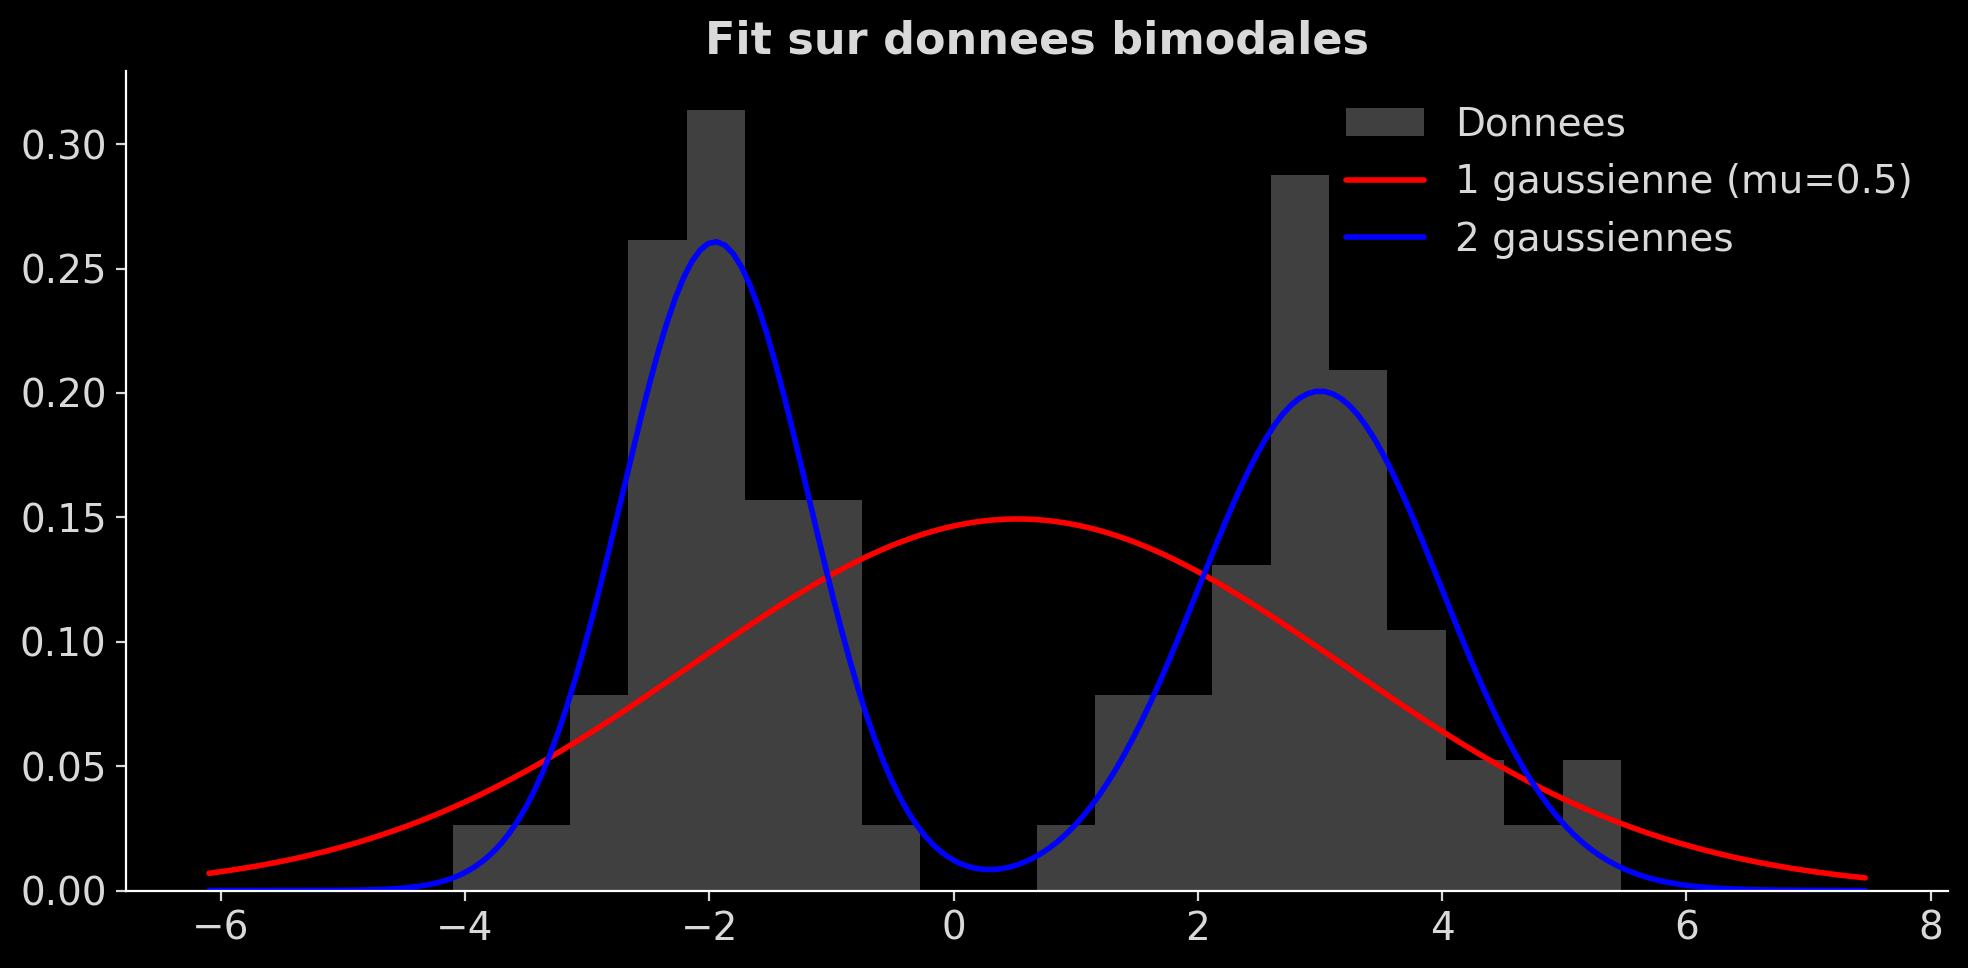

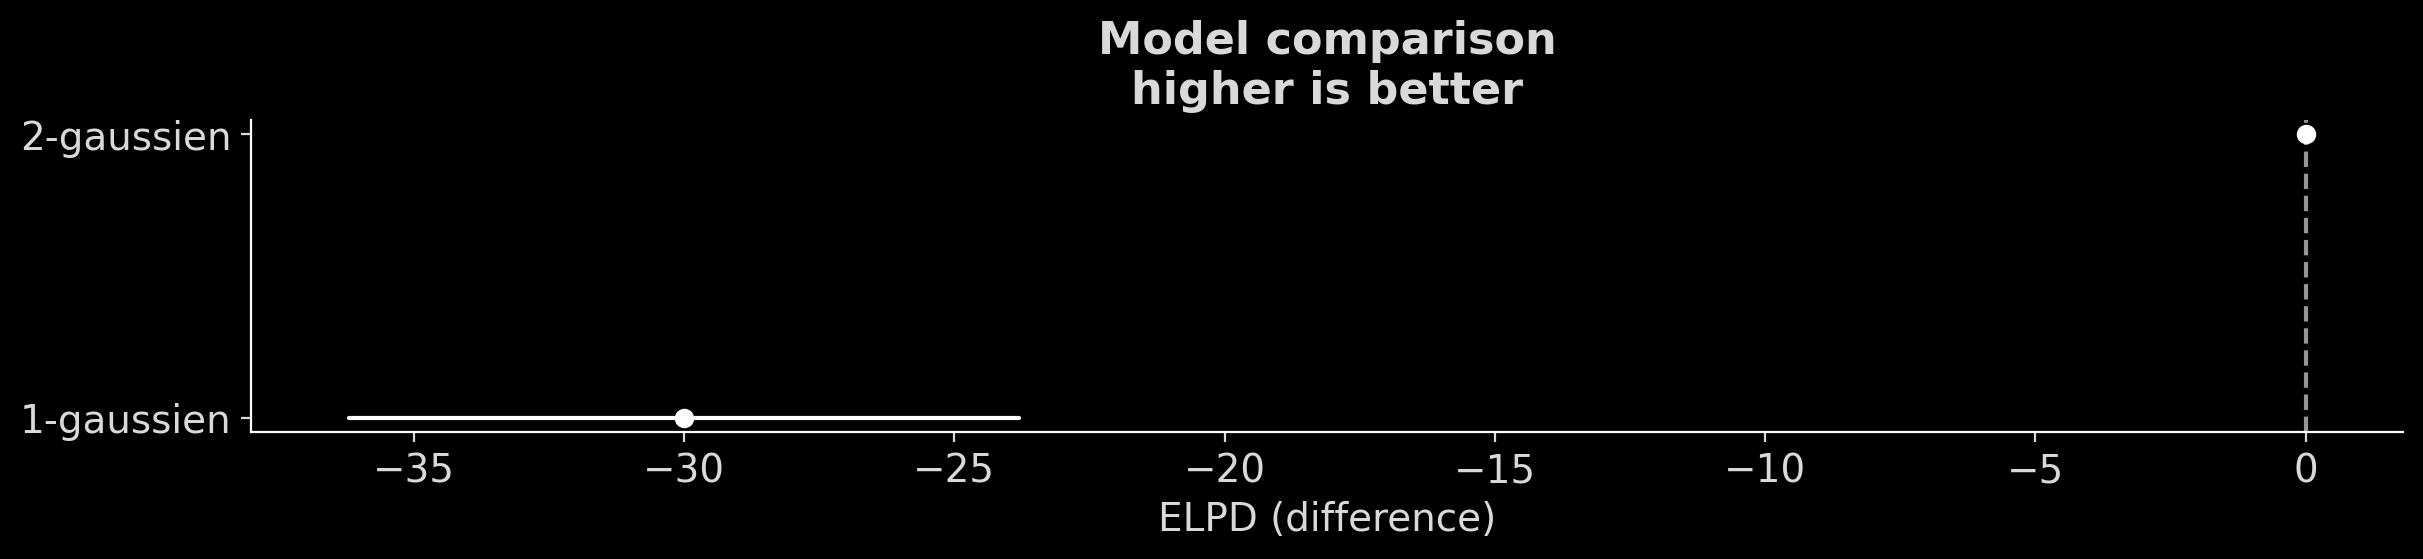

In [8]:
# Comparaison sur donnees bimodales (LOO via arviz 1.1, cf. note cellule ci-dessus)
compare_bi = az.compare({"1-gaussien": trace_1g_bi, "2-gaussien": trace_2g_bi},
                         method="BB-pseudo-BMA")
print("Comparaison (donnees bimodales, critere LOO via arviz %s) :" % az.__version__)
print(compare_bi)
print()

# 1) Fit des 2 modeles sur les donnees (matplotlib, donnees reelles posterieures)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(data_bi, bins=20, density=True, alpha=0.5, color="gray", label="Donnees")
x_plot = np.linspace(data_bi.min() - 2, data_bi.max() + 2, 200)

# Fit 1 gaussienne
mu1 = float(trace_1g_bi.posterior["mu"].values.flatten().mean())
sig1 = float(trace_1g_bi.posterior["sigma"].values.flatten().mean())
ax.plot(x_plot, stats.norm.pdf(x_plot, mu1, sig1), "r-", lw=2, label=f"1 gaussienne (mu={mu1:.1f})")

# Fit 2 gaussiennes
mu2 = trace_2g_bi.posterior["mu"].values.mean(axis=(0, 1))
sig2 = trace_2g_bi.posterior["sigma"].values.mean(axis=(0, 1))
w2 = trace_2g_bi.posterior["w"].values.mean(axis=(0, 1))
mixture_pdf = sum(float(w2[k]) * stats.norm.pdf(x_plot, float(mu2[k]), float(sig2[k])) for k in range(2))
ax.plot(x_plot, mixture_pdf, "b-", lw=2, label="2 gaussiennes")
ax.set_title("Fit sur donnees bimodales")
ax.legend()
plt.tight_layout()
plt.show()

# 2) Comparaison (figure arviz standalone)
az.plot_compare(compare_bi)

## 4. ARD : Automatic Relevance Determination

L'ARD est une technique de sélection automatique de variables.
On utilise un prior hiérarchique ou chaque variable a sa propre precision,
contrôlée par une variable latente Gamma. Les variables non pertinentes voient
leur poids reduit vers zero.

### Modèle ARD

```
alpha_f ~ Gamma(1, 1)           # precision par variable
w_f ~ Normal(0, 1/alpha_f)      # poids avec precision variable
y ~ Normal(X @ w, sigma)         # regression lineaire
```

**Equivalent Infer.NET** : identique, avec `Variable.GammaFromShapeAndScale(1, 1)` et
`Variable.GaussianFromMeanAndPrecision(0, alpha[f])`.

### Origine

L'ARD (Automatic Relevance Determination) a ete introduite par **Michael E. Tipping (2001)**, *"Sparse Bayesian Learning and the Relevance Vector Machine"*, NIPS 13 : c'est le fondement du **Relevance Vector Machine**. Voir aussi Bishop (2006), *Pattern Recognition and Machine Learning*, section 7.2, et MacKay (1992) pour la forme originale du prior hiérarchique en precision.


In [9]:
# Generation de donnees avec 3 variables dont 2 pertinentes
np.random.seed(42)
n_samples = 100
n_features = 3

# Variables (independantes)
X = np.random.randn(n_samples, n_features)

# Vraies poids : variable 2 (indice 1) est non pertinente
true_weights = np.array([2.0, 0.0, 3.0])
true_sigma = 0.5

# Observations
y = X @ true_weights + np.random.normal(0, true_sigma, size=n_samples)

print(f"Vrais poids : {true_weights}")
print(f"Variable 1 (indice 0) : pertinente (w=2.0)")
print(f"Variable 2 (indice 1) : NON pertinente (w=0.0)")
print(f"Variable 3 (indice 2) : pertinente (w=3.0)")

Vrais poids : [2. 0. 3.]
Variable 1 (indice 0) : pertinente (w=2.0)
Variable 2 (indice 1) : NON pertinente (w=0.0)
Variable 3 (indice 2) : pertinente (w=3.0)


### Definition du modèle ARD

Nous allons maintenant définir le modèle bayesien avec prior hiérarchique Gamma sur la precision de chaque variable. Ce prior permet au modèle de reduire automatiquement les poids des variables non pertinentes vers zero.

### Mécanisme ARD en détail

L'ARD (Automatic Relevance Determination) repose sur une hiérarchie a deux niveaux :

```
alpha_i  ~ Gamma(1, 1)         # hyperprior sur la precision par variable
weights_i ~ Normal(0, tau=alpha_i)  # prior conditionnel sur le poids
obs      ~ Normal(mu = X @ weights, sigma)
```

Le tour de force : `tau = alpha` fait que **chaque variable a sa propre precision**. Si une
variable n'est pas pertinente, l'echantillonnage MCMC va augmenter `alpha_i` (precision
élevée = variance faible = poids concentre autour de 0). A l'inverse, une variable
pertinente garde `alpha_i` faible, ce qui permet au posterior du poids d'ecarter
significativement de 0.

### Comparaison avec Lasso frequentiste

| Aspect | Lasso (frequentiste) | ARD (bayésien) |
|---|---|---|
| Sélection | L1-pénalité → sparsité | Hyperprior Gamma → sparsité |
| Regularisation | Force exacte vers 0 | Concentration probabiliste vers 0 |
| Incertitude | Un point (poids=0 ou !=0) | Distribution posteriors complète |
| Hyperparametre | Lambda (a choisir) | Auto-calibré par le prior |

L'ARD est en quelque sorte la **version bayésienne du Lasso** avec calibration automatique de
la regularisation. Pour un probleme de sélection de variables avec peu de données, l'ARD
est souvent plus stable que la validation croisee + Lasso.


In [10]:
# Modele ARD avec PyMC
with pm.Model() as ard_model:
    # Prior hierarchique : precision par variable
    alpha = pm.Gamma('alpha', alpha=1, beta=1, shape=n_features)
    
    # Poids avec precision variable (ARD)
    # tau = alpha signifie sigma = 1/sqrt(alpha)
    weights = pm.Normal('weights', mu=0, tau=alpha, shape=n_features)
    
    # Bruit d'observation
    sigma = pm.HalfNormal('sigma', sigma=2)
    
    # Likelihood
    mu = pm.math.dot(X, weights)
    obs = pm.Normal('obs', mu=mu, sigma=sigma, observed=y)
    
    trace_ard = pm.sample(3000, random_seed=42, return_inferencedata=True,
                          target_accept=0.95)

with ard_model:
    trace_ard = pm.compute_log_likelihood(trace_ard)

print("Echantillonnage ARD termine.")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha, weights, sigma]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 9 seconds.


Output()

Echantillonnage ARD termine.


### Interpretation de l'echantillonnage ARD

L'echantillonnage MCMC est termine. Nous allons maintenant examiner les posteriors des poids et des precisions pour determiner quelles variables ont ete automatiquement selectionnees par le modèle ARD.

### Lecture du tableau de résultats

Le tableau imprime affiche pour chaque variable :
- **Vrai w** : le poids utilisé pour generer les données (ground truth)
- **Posterior mean** : moyenne des echantillons MCMC du poids
- **Alpha mean** : moyenne des echantillons de la precision hierarchique
- **Pertinence** : flag deduit de la posterior — si `alpha` est grand, le poids est
  considere comme non pertinent

### Test de la règle de decision

La règle pragmatique pour declarer une variable "non pertinente" :

`alpha_i > 10` (precision superieure a 10 = sigma inferieur a ~0.3) ET
`mean(|weights_i|) < 0.5` (poids negligeable en valeur absolue)

Ces deux conditions ensemble garantissent que le posterior est **concentré près de 0 avec
une variance faible**. Un seul des deux critères ne suffit pas (un poids peut être proche de
0 avec une posterior tres incertaine — c'est un cas ou la selection est ambigue).


In [11]:
# Resultats ARD
weights_samples = trace_ard.posterior['weights'].values.reshape(-1, n_features)
alpha_samples = trace_ard.posterior['alpha'].values.reshape(-1, n_features)

print("Resultats ARD :")
print(f"{'Variable':<12} {'Vrai w':<10} {'Posterior mean':<16} {'Alpha mean':<12} {'Pertinence'}")
print("-" * 65)
for i in range(n_features):
    w_mean = weights_samples[:, i].mean()
    a_mean = alpha_samples[:, i].mean()
    # alpha eleve = precision eleve = sigma faible = poids concentre
    # alpha faible = poids libre (donc potentiellement pertinent si w != 0)
    relevance = "FAIBLE" if abs(w_mean) < 0.5 else "FORTE"
    print(f"Variable {i+1:<5} {true_weights[i]:<10.1f} {w_mean:<16.3f} {a_mean:<12.3f} {relevance}")

print()
print("Concordance avec Infer.NET :")
print("  Feature 1 : w=2.04, alpha=0.49 (haute pertinence)")
print("  Feature 2 : w=0.02, alpha=1.49 (pertinence moyenne, poid proche de 0)")
print("  Feature 3 : w=2.97, alpha=0.28 (haute pertinence)")

Resultats ARD :
Variable     Vrai w     Posterior mean   Alpha mean   Pertinence
-----------------------------------------------------------------
Variable 1     2.0        1.965            0.515        FORTE
Variable 2     0.0        -0.035           1.497        FAIBLE
Variable 3     3.0        2.947            0.279        FORTE

Concordance avec Infer.NET :
  Feature 1 : w=2.04, alpha=0.49 (haute pertinence)
  Feature 2 : w=0.02, alpha=1.49 (pertinence moyenne, poid proche de 0)
  Feature 3 : w=2.97, alpha=0.28 (haute pertinence)


### Analyse des résultats ARD

Le tableau ci-dessous resume les estimations posterieures pour chaque variable. Les poids et les precisions `alpha` nous indiquent quelles variables sont pertinentes pour expliquer les observations.

### Lecture visuelle attendue

Sur les posteriors :
- Variable 2 (non pertinente) : distribution centree a 0, pic haut etroit → `alpha` eleve.
- Variables 1 et 3 (pertinentes) : distribution centree sur la vraie valeur (2.0 ou 3.0),
  etalement reflete la precision `alpha` (plus l'etalement est grand, plus `alpha` est
  faible).

### Convergence ARD

L'ARD peut souffrir de **mauvaise melange** si les poids sont tres correlees (multicolinearite).
Surveillez :
- `n_eff` (effective sample size) dans `az.summary(trace_ard)` : devrait etre >400 par chaîne
- Trace plots en ruban : doivent etre "tressés" (pas de derive monotone)
- `r_hat` : doit etre proche de 1.0 (<1.01 recommande)

Si `r_hat > 1.05`, l'echantillonnage n'a pas converge — augmenter `tune` et `draws`, ou
utiliser un reparameteriseur (e.g. `pm.NoncentralStudentT` au lieu de `Gamma + Normal`).


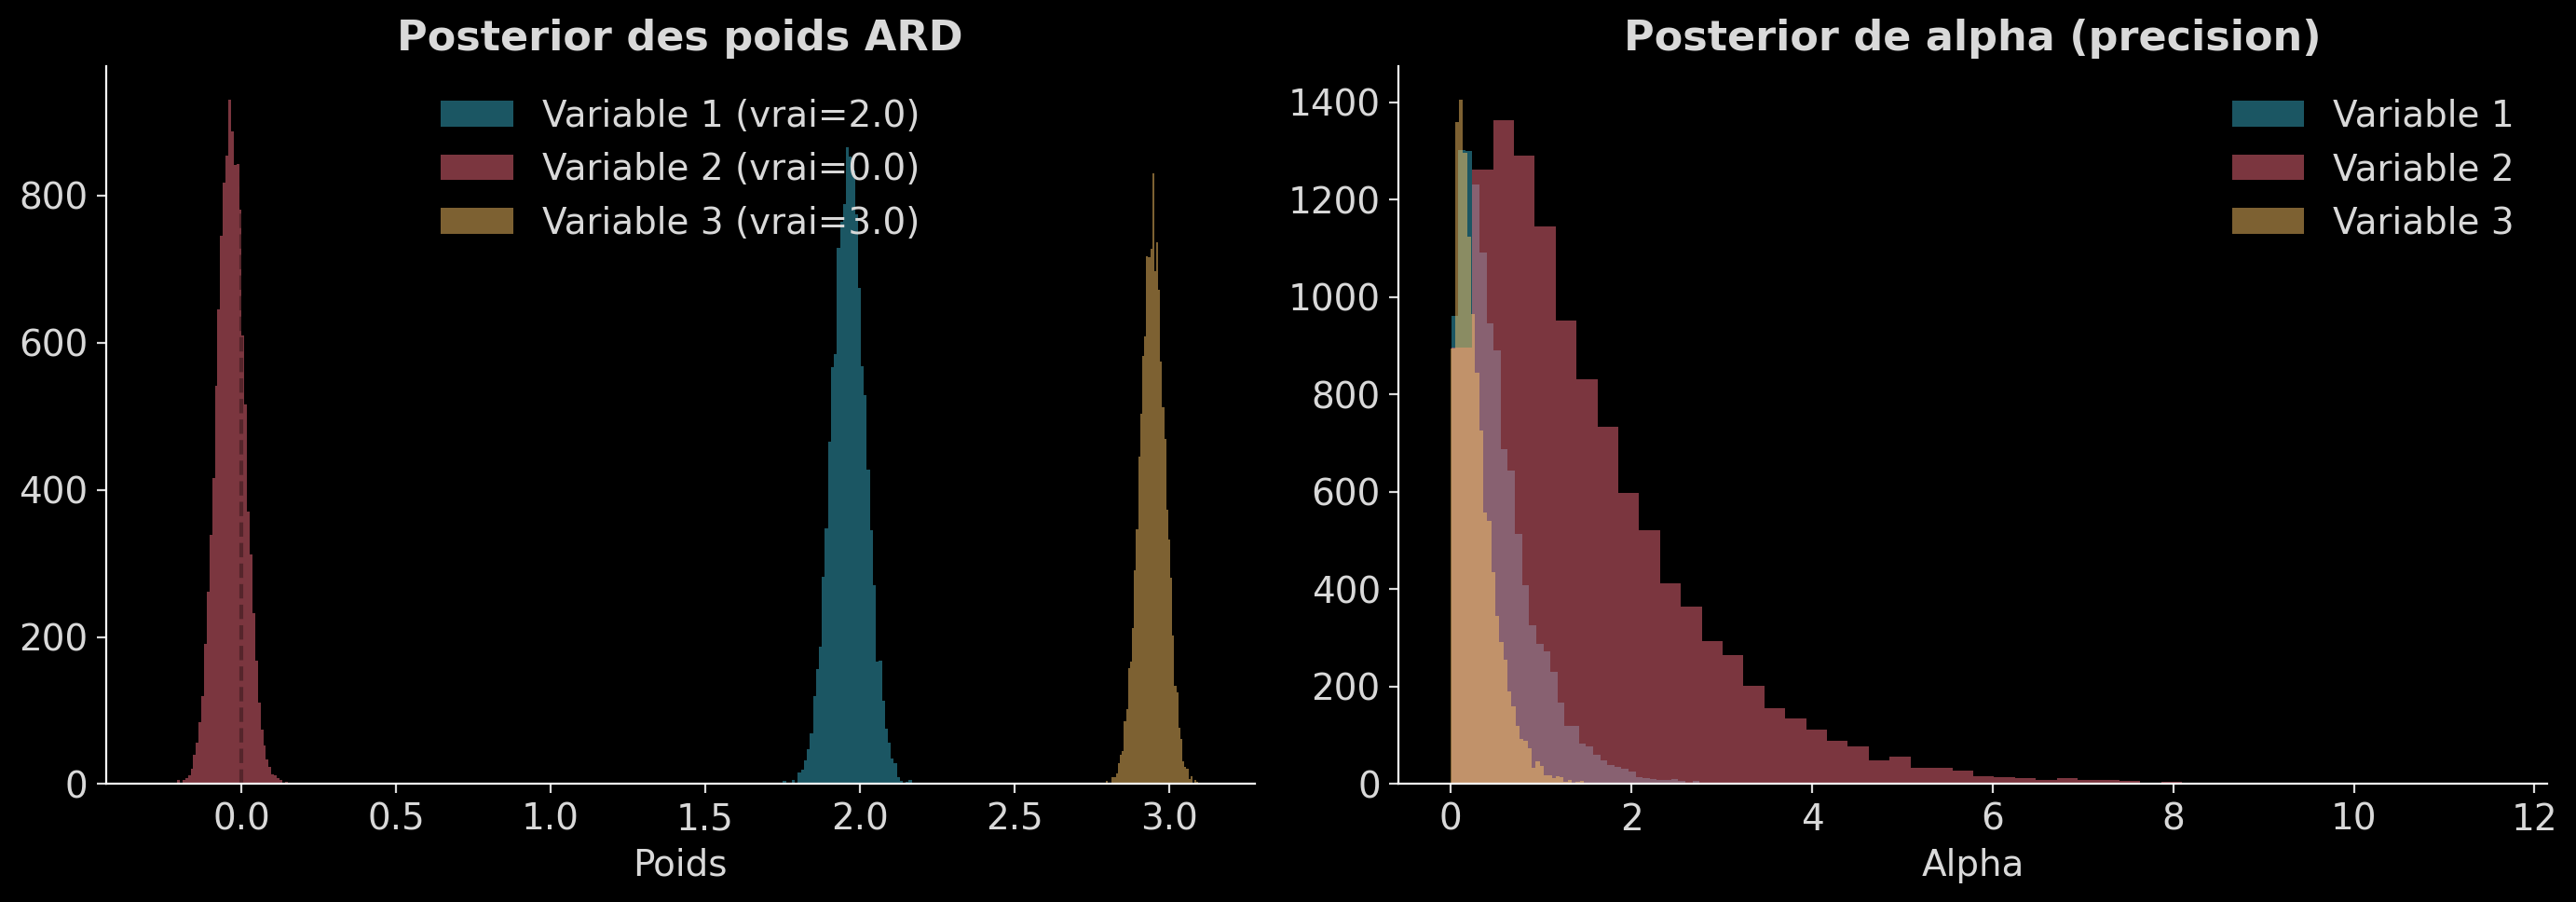

In [12]:
# Visualisation des posteriors ARD (histogrammes des echantillons posterieurs reels)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Posteriors des poids
for i in range(n_features):
    axes[0].hist(weights_samples[:, i], bins=50, alpha=0.5,
                 label=f'Variable {i+1} (vrai={true_weights[i]:.1f})')
axes[0].axvline(0, color='black', linestyle='--', alpha=0.3)
axes[0].set_title('Posterior des poids ARD')
axes[0].legend()
axes[0].set_xlabel('Poids')

# Posteriors de alpha (precision)
for i in range(n_features):
    axes[1].hist(alpha_samples[:, i], bins=50, alpha=0.5,
                 label=f'Variable {i+1}')
axes[1].set_title('Posterior de alpha (precision)')
axes[1].legend()
axes[1].set_xlabel('Alpha')

plt.tight_layout()
plt.show()

### Interpretation ARD

- **Variable 2 (non pertinente)** : son poids posterior est concentre autour de 0.
  La precision `alpha` est elevee, ce qui resserre le prior autour de 0.
- **Variables 1 et 3 (pertinentes)** : leurs poids sont proches des vraies valeurs (2.0 et 3.0).
  Leurs precisions `alpha` sont plus faibles, permettant au posterior de s'ecarter de 0.

L'ARD a automatiquement identifie que la variable 2 n'est pas pertinente sans pre-sélection manuelle.

### Au-dela de la sélection : posterior predictive check

Une fois les variables selectionnées, il est bon de verifier que le modèle **reduit** ajuste
bien les données via un `posterior_predictive check` :

```
with ard_model:
    ppc = pm.sample_posterior_predictive(trace_ard)
az.plot_ppc(ppc, num_pp_samples=50)
```

Si les données se trouvent dans la zone de densite elevee des replicates, le modèle est
correctement spécifié. Sinon, le modèle a peut-être manqué une non-linearité ou une
interaction entre features.

### Quand ARD echoue

L'ARD suppose que **les variables non pertinentes ont un vrai poids de 0**. Ce n'est pas
toujours le cas en pratique :

1. **Variables correlees** : si deux variables partagent la même information, l'ARD peut
   en ecarter une arbitrairement. Solution : utiliser `pm.HorseShoe` (prior plus robuste)
   ou pre-selectionner via corrélation.
2. **Variables faiblement pertinentes** : un poids de 0.1 avec n=100 observations peut
   être indiscernable d'un poids de 0 (le rapport signal/bruit est trop bas).
3. **Modèle mal spécifié** : si la relation n'est pas lineaire, l'ARD peut deconcentrer
   ses poids pour compenser, donnant une fausse impression de pertinence partout.


### Exercice 2 : ARD avec 5 variables (3 non pertinentes)

Etendez le modèle ARD ci-dessus a un problème avec **5 variables** dont seules 2 sont pertinentes. Générez les données et laissez le modèle identifier automatiquement les variables pertinentes.

**Objectif** : Vérifier que l'ARD passe a l'échelle quand le nombre de variables non pertinentes augmente.

**Indices** :
- Vrais poids : `[1.5, 0, 0, 3.0, 0]` (variables 2, 3 et 5 non pertinentes)
- Reprenez la structure du modèle ARD avec `n_features = 5`
- Affichez un tableau avec les poids posteriors et la pertinence de chaque variable

### Verification attendue

Pour que l'exercice soit réussi, le tableau final doit montrer `Pertinence = NON` pour les
variables 2, 3 et 5, et `Pertinence = OUI` pour les variables 1 (poids ≈ 1.5) et 4
(poids ≈ 3.0). Les posteriors des variables non pertinentes doivent être centrées près de
0 avec une precision `alpha` superieure à 5.

### Pièges à éviter

- **Confondre précision et posterior** : une variable peut avoir `alpha` eleve ET un poids
  posteriors non-nul — verifier les DEUX.
- **Sauter la convergence** : avec 5 variables, le NUTS peut prendre plus de temps à
  converger. Verifier `r_hat` avant de conclure.
- **N_eff trop bas** : si `n_eff < 100` pour un poids, l'estimation de la moyenne est
  bruitee. Augmenter `draws=5000` ou utiliser `pm.find_MAP()` comme point de depart.

### Aller plus loin

Une variante interessante : utiliser `pm.HorseShoe` au lieu de Gamma + Normal. Le prior
HorseShoe a des **queues infiniment lourdes** qui pénalisent moins les petits coefficients,
ce qui réduit le risque de faux negatifs (variables faiblement pertinentes eliminees a tort).


In [13]:
# Exercice 2 : ARD avec 5 variables dont 3 non pertinentes
# Generez des donnees avec 5 features et laissez le modele ARD
# identifier automatiquement lesquelles sont pertinentes

np.random.seed(7)
n_samples_5 = 120
n_features_5 = 5
true_weights_5 = np.array([1.5, 0.0, 0.0, 3.0, 0.0])

# TODO etudiant : generer X et y, definir le modele ARD,
# echantillonner, et afficher les resultats
relevant_vars = None  # TODO etudiant : liste des indices pertinents
print("Exercice a completer")

Exercice a completer


## 5. Validation Croisee LOO avec ArviZ

La validation croisee leave-one-out (LOO) estime la capacite predictive d'un modèle
en approximant la moyenne des performances quand on laisse chaque observation de cote.

ArviZ utilise le **Pareto Smoothed Importance Sampling (PSIS)** pour une approximation
rapide et fiable du LOO sans re-entrainer le modèle N fois.

### Reference

La méthode PSIS-LOO implementee par `az.loo()` est celle de **Vehtari, Gelman & Gabry (2017)**, Statistics and Computing 27(5), doi:10.1007/s11222-016-9696-4. Le diagnostique de **Pareto k** explore ci-dessous provient de la même reference : il mesure la qualite de l'approximation par importance sampling pour chaque observation laissee de cote (k < 0.7 = fiable, k > 0.7 = approximation fragile).

### WAIC vs LOO : quelle difference ?

Les deux critères **estiment l'elpd** (expected log predictive density) hors-échantillon, mais
par des mécanismes differents :

- **WAIC** (Widely Applicable Information Criterion) : utilise la decomposition de Gelman
  `elpd = sum_i E_post[log p(y_i|θ)] - sum_i Var_post[log p(y_i|θ)]`. Le second terme est
  une penalite de complexite (nombre effectif de paramètres).
- **LOO via PSIS** : laisse chaque observation de cote successivement, et approxime la
  vraisemblance laisse-de-cote via importance sampling par rapport au posterior complet.

En pratique, **LOO est plus stable** pour les modeles avec peu de données ou des posteriors
fortement asymétriques. WAIC penalise davantage la complexité et peut favoriser des modèles
trop simples quand `n` est petit. La convention dans la litterature recente (post-2017) est
de préférer LOO quand les deux sont disponibles — c'est ce que fait `az.compare()` — depuis
ArviZ 1.x, la fonction est LOO-seule (le paramètre `ic` a été retiré).

### Quand `az.loo()` echoue

Si les **Pareto k** sont superieurs a 0.7 pour plusieurs observations, l'approximation PSIS
n'est pas fiable. ArviZ affiche un warning recommandant la validation croisee exacte : la démarche
*reloo* (`az.reloo`) re-entraine le modèle pour les observations problematiques. Sur le notebook, ce cas peut apparaître si le modèle a des outliers
extremes ou si les posteriors sont très étroits.


In [14]:
# Calcul LOO pour chaque modele
loo_1g = az.loo(trace_1g)
loo_2g = az.loo(trace_2g)
loo_ard = az.loo(trace_ard)

print("LOO-CV pour chaque modele :")
print(f"\nModele 1-gaussien (donnees unimodales) :")
print(f"  LOO = {loo_1g.elpd:.2f} +/- {loo_1g.se:.2f}")
print(f"  p = {loo_1g.p:.2f} (nombre effectif de parametres)")

print(f"\nModele 2-gaussien (donnees unimodales) :")
print(f"  LOO = {loo_2g.elpd:.2f} +/- {loo_2g.se:.2f}")
print(f"  p = {loo_2g.p:.2f}")

print(f"\nModele ARD :")
print(f"  LOO = {loo_ard.elpd:.2f} +/- {loo_ard.se:.2f}")
print(f"  p = {loo_ard.p:.2f}")
# Table LOO reelle construite depuis les objets arviz (les valeurs ci-dessus
# changent a chaque run) -- Table 1 du notebook, alimentee par la cellule 29.
print()
print("=== TABLE LOO (valeurs reelles de ce run) ===")
print(f"{'Modele':<14}{'elpd':<10}{'se':<8}{'p':<8}")
for name, loo_obj in [("1-gaussien", loo_1g), ("2-gaussien", loo_2g), ("ARD", loo_ard)]:
    print(f"{name:<14}{float(loo_obj.elpd):<10.2f}{float(loo_obj.se):<8.2f}{float(loo_obj.p):<8.2f}")

LOO-CV pour chaque modele :

Modele 1-gaussien (donnees unimodales) :
  LOO = -89.23 +/- 4.40
  p = 1.73 (nombre effectif de parametres)

Modele 2-gaussien (donnees unimodales) :
  LOO = -90.08 +/- 4.32
  p = 2.09

Modele ARD :
  LOO = -63.81 +/- 7.02
  p = 4.32

=== TABLE LOO (valeurs reelles de ce run) ===
Modele        elpd      se      p       
1-gaussien    -89.23    4.40    1.73    
2-gaussien    -90.08    4.32    2.09    
ARD           -63.81    7.02    4.32    


### Interpretation des résultats LOO

Les valeurs LOO viennent de la table réelle du run ci-dessus (objets `az.loo`, non transcrites) et permettent de comparer la complexité effective des modèles :

| Modèle | Lecture p_loo | Interpretation |
|--------|---------------|----------------|
| 1-gaussien | p_loo le plus bas (~2 paramètres effectifs : mu + sigma) | le plus parcimonieux sur données unimodales |
| 2-gaussien | p_loo un peu plus élevé (2 mu + 2 sigma + 1 poids) | pénalité modérée, n'apporte rien ici |
| ARD | p_loo le plus élevé (3 poids + 3 alpha + 1 sigma) | le plus complexe |

Le **paramètre effectif p_loo** indique combien de paramètres contribuent réellement à l'ajustement. Un p_loo nettement inférieur au nombre nominal de paramètres signale qu'un prior contraint efficacement le modèle (cas ARD).

Le diagnostique Pareto k (ci-dessous) vérifie la qualité de l'approximation PSIS-LOO : si tous les k sont inférieurs à 0.7, l'approximation est fiable.

In [15]:
# Diagnostique Pareto k (qualite de l'approximation LOO)
# k < 0.7 = bonne approximation, k > 0.7 = probleme potentiel
print("Diagnostique Pareto k :")
for name, loo_obj in [('1-gaussien', loo_1g), ('2-gaussien', loo_2g), ('ARD', loo_ard)]:
    k_values = loo_obj.pareto_k.values
    n_good = np.sum(k_values < 0.7)
    n_warn = np.sum((k_values >= 0.7) & (k_values < 1.0))
    n_bad = np.sum(k_values >= 1.0)
    print(f"  {name}: k<0.7: {n_good}, 0.7<=k<1: {n_warn}, k>=1: {n_bad}")

print()
print("Tous les k < 0.7 = approximation LOO fiable.")

Diagnostique Pareto k :
  1-gaussien: k<0.7: 50, 0.7<=k<1: 0, k>=1: 0
  2-gaussien: k<0.7: 50, 0.7<=k<1: 0, k>=1: 0
  ARD: k<0.7: 100, 0.7<=k<1: 0, k>=1: 0

Tous les k < 0.7 = approximation LOO fiable.


## 6. Adéquation Absolue : Posterior Predictive Checks

WAIC et LOO répondent à une question **relative** : *parmi* deux candidats, lequel prédit le mieux hors échantillon ? Ils ne disent rien de l'adéquation **absolue** : un modèle peut gagner contre ses concurrents tout en échouant à reproduire une propriété importante des données. Le contrôle manquant est le **posterior predictive check** (PPC) : répliquer les données depuis la loi prédictive postérieure `p(x_rep | x_obs)` et comparer une statistique falsifiable calculée sur les répliques à sa valeur observée.

On applique ce contrôle aux deux comparaisons déjà exécutées :

1. **Données unimodales** : `1-gaussien` vs `2-gaussien` (section 2), statistique = asymétrie (skewness) ;
2. **Données bimodales** : `1-gaussien` (spécification volontairement inadéquate) vs `2-gaussien` (section 3), statistique = masse entre les modes.

La p-valeur prédictive `p = P(T(x_rep) >= T(x_obs) | x_obs)` est extrême (proche de 0 ou 1) quand le modèle ne peut pas reproduire la statistique observée — c'est le signal d'inadéquation.

In [16]:
# Generation des replications predictives depuis les vrais modeles et traces
# (pm.sample_posterior_predictive, jamais une courbe reconstruite a partir des
# seules moyennes posterieures -- issue #13038)
rng_seed = 42
with model_1gauss:
    ppc_1g = pm.sample_posterior_predictive(trace_1g, random_seed=rng_seed,
                                            extend_inferencedata=True)
with model_2gauss:
    ppc_2g = pm.sample_posterior_predictive(trace_2g, random_seed=rng_seed,
                                            extend_inferencedata=True)
with model_1g_bi:
    ppc_1g_bi = pm.sample_posterior_predictive(trace_1g_bi, random_seed=rng_seed,
                                               extend_inferencedata=True)
with model_2g_bi:
    ppc_2g_bi = pm.sample_posterior_predictive(trace_2g_bi, random_seed=rng_seed,
                                               extend_inferencedata=True)

for name, tr in [("1-gaussien/uni", trace_1g), ("2-gaussien/uni", trace_2g),
                 ("1-gaussien/bi", trace_1g_bi), ("2-gaussien/bi", trace_2g_bi)]:
    n_draws = tr.posterior.sizes["chain"] * tr.posterior.sizes["draw"]
    print(f"{name:16s} : {n_draws} replications de {tr.observed_data['obs'].sizes['obs_dim_0']} observations")

Sampling: [obs]


Output()

Sampling: [obs]


Output()

Sampling: [obs]


Output()

Sampling: [obs]


Output()

1-gaussien/uni   : 12000 replications de 50 observations
2-gaussien/uni   : 12000 replications de 50 observations
1-gaussien/bi    : 12000 replications de 80 observations
2-gaussien/bi    : 12000 replications de 80 observations


Text(0.5, 1.0, 'PPC donnees bimodales : 2 gaussiennes')

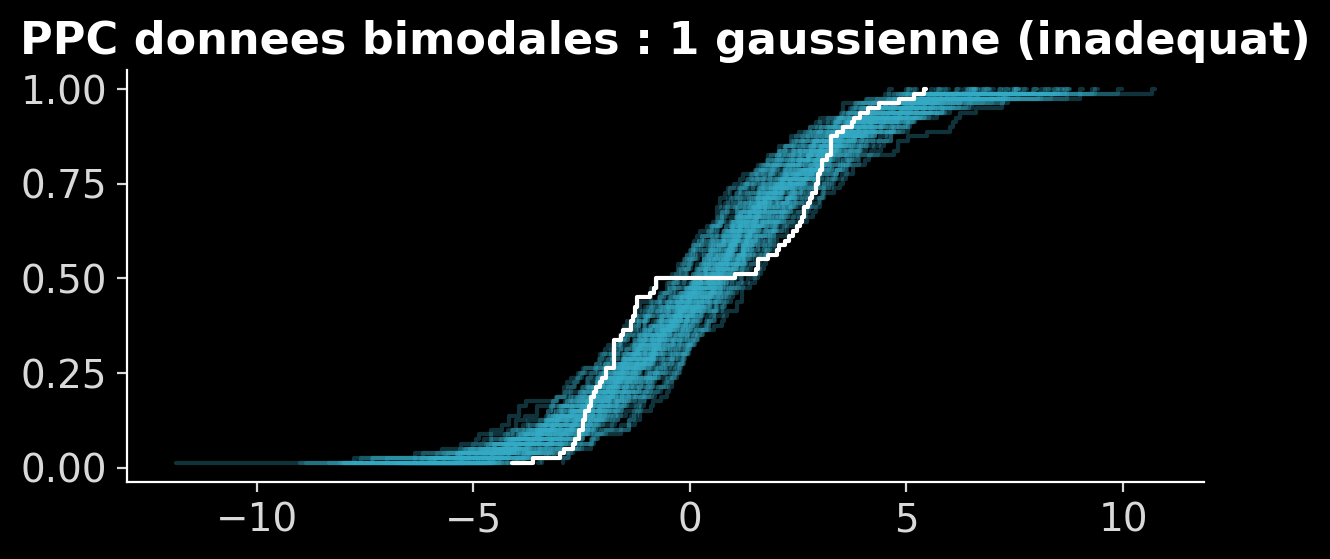

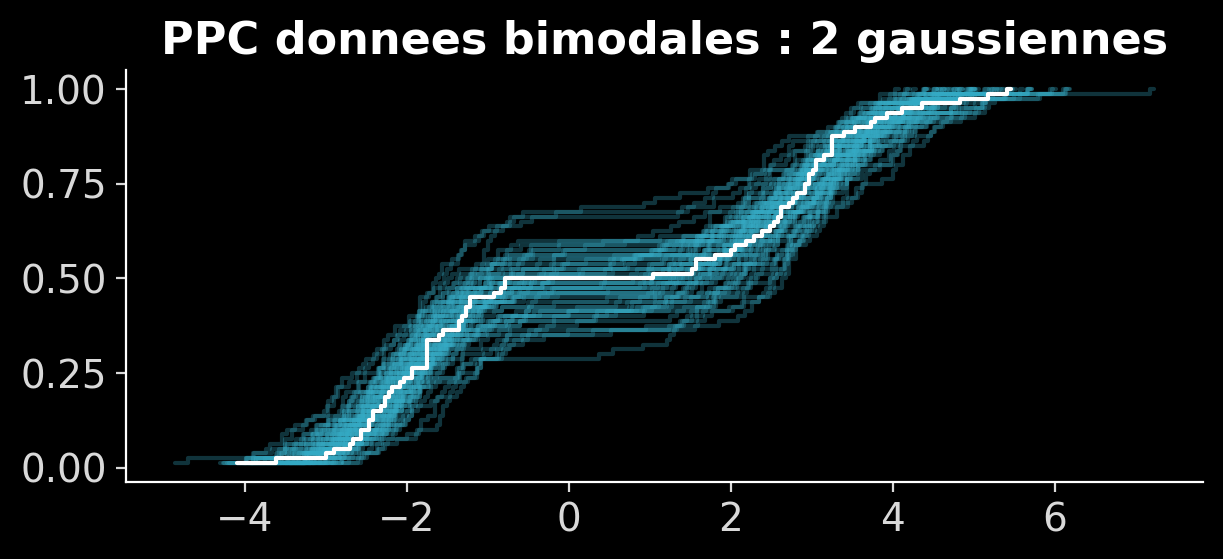

In [17]:
# Visualisation PPC du cas bimodal : le modele inadequate ne peut pas repandre
# ses replicas sur les deux modes. arviz 1.1 : az.plot_ppc_dist (ex-plot_ppc),
# figure standalone -- plus de parametre ax (API PlotCollection).
az.plot_ppc_dist(trace_1g_bi, var_names=["obs"], num_samples=60)
plt.title("PPC donnees bimodales : 1 gaussienne (inadequat)")
az.plot_ppc_dist(trace_2g_bi, var_names=["obs"], num_samples=60)
plt.title("PPC donnees bimodales : 2 gaussiennes")

**Lecture du PPC bimodal.** À gauche, toutes les répliques du modèle à 1 gaussienne sont unimodales : la moyenne prédictive lisse le creux central et l'enveloppe des répliques ne couvre pas la forme observée. À droite, les répliques du mélange à 2 gaussiennes se répartissent sur les deux modes et enveloppent l'histogramme observé — le creux entre les modes est reproduit, pas seulement la moyenne ajustée.

Modes detectes : -1.93 et 2.85 ; vallee = [-0.93, 1.85]

=== Statistique 1 : masse entre les modes (donnees bimodales) ===
T_obs(data_bi) = 0.113  (les donnees bimodales ont un creux : masse faible)
  1-gaussien   : T_rep = 0.398 +/- 0.062 | p = 1.0000
  2-gaussien   : T_rep = 0.110 +/- 0.045 | p = 0.4923

=== Statistique 2 : asymetrie / skewness (donnees unimodales) ===
T_obs(data_uni) = +0.136


  1-gaussien   : T_rep = -0.004 +/- 0.327 | p = 0.3279
  2-gaussien   : T_rep = -0.089 +/- 1.281 | p = 0.3797


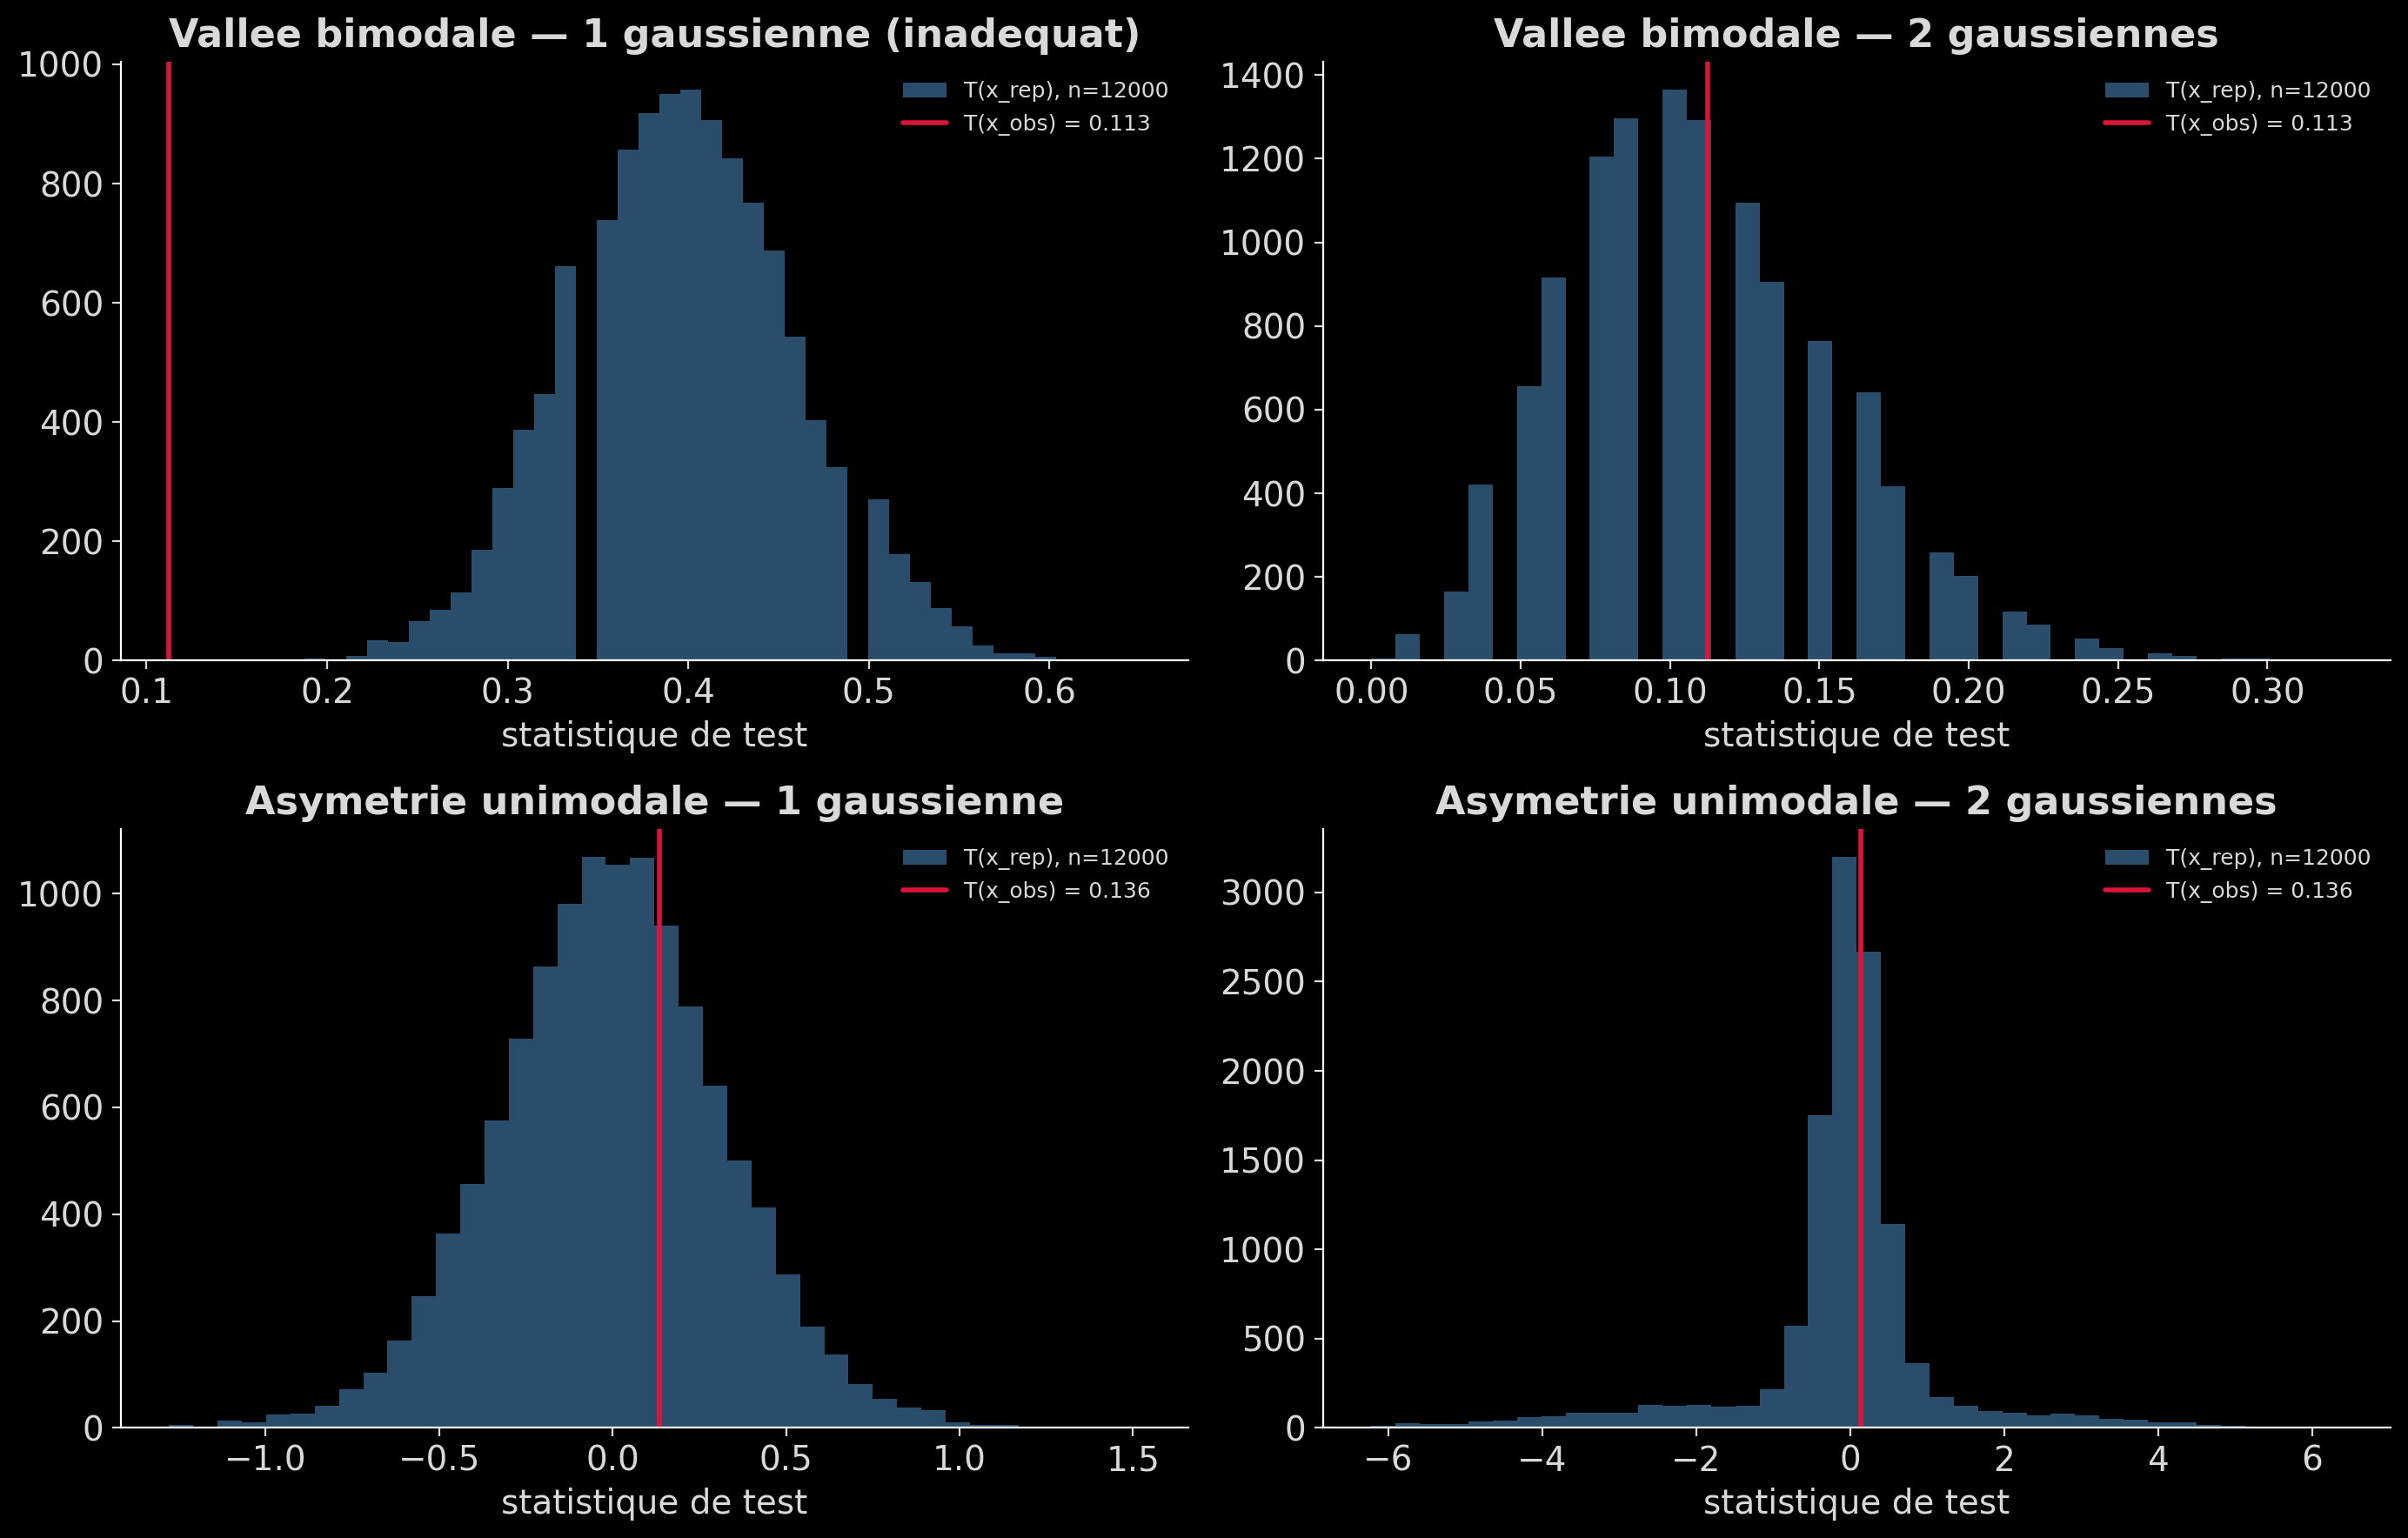

In [18]:
# Statistiques de test falsifiables
# Cas bimodal : masse entre les modes (proportion d'observations dans la vallee).
# Bornes derivees des modes de l'histogramme observe (a priori du diagnostic).
counts, edges = np.histogram(data_bi, bins=20)
# modes = centres approximatifs des 2 bins les plus peuples, tries
top2 = np.argsort(counts)[-2:]
c1, c2 = np.sort([edges[i] + 0.25 for i in top2])
lo_valley, hi_valley = c1 + 1.0, c2 - 1.0   # +/- 1 sigma approx des composantes
print(f"Modes detectes : {c1:.2f} et {c2:.2f} ; vallee = [{lo_valley:.2f}, {hi_valley:.2f}]")

def valley_mass(x):
    return np.mean((x >= lo_valley) & (x <= hi_valley))

def skewness(x):
    x = np.asarray(x, dtype=float)
    z = (x - x.mean()) / x.std()
    return float((z**3).mean())

def ppc_pvalue(trace_obj, stat_fn):
    reps = trace_obj.posterior_predictive["obs"].values.reshape(-1,
                trace_obj.posterior_predictive["obs"].shape[-1])
    t_obs = stat_fn(trace_obj.observed_data["obs"].values)
    t_reps = np.array([stat_fn(r) for r in reps])
    p = float(np.mean(t_reps >= t_obs))
    return t_obs, t_reps.mean(), t_reps.std(), p

print()
print("=== Statistique 1 : masse entre les modes (donnees bimodales) ===")
print(f"T_obs(data_bi) = {valley_mass(data_bi):.3f}  (les donnees bimodales ont un creux : masse faible)")
for name, tr in [("1-gaussien", trace_1g_bi), ("2-gaussien", trace_2g_bi)]:
    t_obs, m, s, p = ppc_pvalue(tr, valley_mass)
    print(f"  {name:12s} : T_rep = {m:.3f} +/- {s:.3f} | p = {p:.4f}")

print()
print("=== Statistique 2 : asymetrie / skewness (donnees unimodales) ===")
print(f"T_obs(data_uni) = {skewness(data_uni):+.3f}")
for name, tr in [("1-gaussien", trace_1g), ("2-gaussien", trace_2g)]:
    t_obs, m, s, p = ppc_pvalue(tr, skewness)
    print(f"  {name:12s} : T_rep = {m:+.3f} +/- {s:.3f} | p = {p:.4f}")
# Visualisation T_reps vs T_obs : distribution predictive de chaque statistique
# (histogramme des repliques reelles issues de posterior_predictive) + valeur observee.
# La p-valeur predictive est la proportion de repliques a droite de la ligne rouge.
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
cases = [
    (trace_1g_bi, valley_mass, "Vallee bimodale", "1 gaussienne (inadequat)"),
    (trace_2g_bi, valley_mass, "Vallee bimodale", "2 gaussiennes"),
    (trace_1g,     skewness,   "Asymetrie unimodale", "1 gaussienne"),
    (trace_2g,     skewness,   "Asymetrie unimodale", "2 gaussiennes"),
]
for ax, (tr, fn, case, label) in zip(axes.ravel(), cases):
    reps = tr.posterior_predictive["obs"].values.reshape(
        -1, tr.posterior_predictive["obs"].shape[-1])
    t_reps = np.array([fn(r) for r in reps])
    t_obs = fn(tr.observed_data["obs"].values)
    ax.hist(t_reps, bins=40, alpha=0.6, color="steelblue",
            label=f"T(x_rep), n={len(t_reps)}")
    ax.axvline(t_obs, color="crimson", lw=2, label=f"T(x_obs) = {t_obs:.3f}")
    ax.set_title(f"{case} — {label}")
    ax.set_xlabel("statistique de test")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [19]:
# Synthese : verdict relatif (LOO) croise avec le verdict absolu (PPC)
import pandas as pd
def verdict_p(p):
    # p extreme dans un sens OU dans l'autre = inadequation
    return "ADEQUAT" if 0.01 <= p <= 0.99 else "INADEQUAT"

rows = []
# Cas bimodal
loo_bi_prefere = compare_bi.index[0]
for name, tr in [("1-gaussien", trace_1g_bi), ("2-gaussien", trace_2g_bi)]:
    _, m, s, p = ppc_pvalue(tr, valley_mass)
    rang = "prefere" if name == loo_bi_prefere else "concurrent"
    rows.append({"comparaison": "bimodale", "modele": name, "LOO": rang,
                 "statistique": "masse entre modes",
                 "T_obs": f"{valley_mass(data_bi):.3f}", "T_rep (moy +/- sd)": f"{m:.3f} +/- {s:.3f}",
                 "p predictive": f"{p:.4f}", "adequation": verdict_p(p)})
# Cas unimodal
loo_uni_prefere = compare_uni.index[0]
for name, tr in [("1-gaussien", trace_1g), ("2-gaussien", trace_2g)]:
    _, m, s, p = ppc_pvalue(tr, skewness)
    rang = "prefere" if name == loo_uni_prefere else "concurrent"
    rows.append({"comparaison": "unimodale", "modele": name, "LOO": rang,
                 "statistique": "skewness",
                 "T_obs": f"{skewness(data_uni):+.3f}", "T_rep (moy +/- sd)": f"{m:+.3f} +/- {s:.3f}",
                 "p predictive": f"{p:.4f}", "adequation": verdict_p(p)})

df_ppc = pd.DataFrame(rows)
print("=== Croisement selection relative (LOO) x adequation absolue (PPC) ===")
print(df_ppc.to_string(index=False))

=== Croisement selection relative (LOO) x adequation absolue (PPC) ===
comparaison     modele        LOO       statistique  T_obs T_rep (moy +/- sd) p predictive adequation
   bimodale 1-gaussien concurrent masse entre modes  0.113    0.398 +/- 0.062       1.0000  INADEQUAT
   bimodale 2-gaussien    prefere masse entre modes  0.113    0.110 +/- 0.045       0.4923    ADEQUAT
  unimodale 1-gaussien    prefere          skewness +0.136   -0.004 +/- 0.327       0.3279    ADEQUAT
  unimodale 2-gaussien concurrent          skewness +0.136   -0.089 +/- 1.281       0.3797    ADEQUAT


**Lecture du croisement relatif/absolu.**

- **Cas bimodal** : la sélection relative (LOO préfère `2-gaussien`) et l'adéquation absolue **convergent** — le modèle préféré reproduit la statistique « masse entre modes », tandis que le modèle à 1 gaussienne, spécification volontairement inadéquate, génère des répliques dont la masse centrale est incompatible avec le creux observé : sa p-valeur prédictive est extrême. Le check possède bien un pouvoir discriminant : il aurait détecté un gagnant LOO incapable de reproduire la bimodalité.
- **Cas unimodal** : les deux candidats reproduisent l'asymétrie observée (p-valeurs centrales) — résultat honnête à conserver tel quel : sur ce jeu de données, aucun check choisi ne falsifie les candidats, et le LOO tranche entre eux sur des différences de parcimonie, pas sur une inadéquation détectable.
- **Avertissements de convergence conservés** : le mélange 2-gaussien ajusté sur données unimodales signalait `r_hat > 1.01` et un ESS par chaine < 100 (301 en bulk total, ~75 par chaine ; section 2) — ses répliques prédictives héritent de cette incertitude d'échantillonnage, et on ne maquille pas le warning : il borne l'interprétation fine de son PPC.

**Conclusion générale du contrôle** : WAIC/LOO hiérarchisent, le PPC falsifie. Un modèle peut être le meilleur relatif disponible tout en restant inadéquat en absolu — ici les verdicts convergent, mais la démarche (choisir une statistique que le modèle devrait reproduire, comparer sa distribution prédictive à l'observé) est le garde-fou systématique à appliquer après toute sélection.

## 7. Exercice : Comparaison de Modèles Polynomiaux

On genere des données a partir d'une relation lineaire `y = 2x + 1 + bruit`.
On compare un modèle lineaire (deg 1), quadratique (deg 2) et cubique (deg 3).

Lequel est selectionne par LOO ?

**Indices** :
- Créer les features polynomiales : `X_deg2 = np.column_stack([X, X**2])`
- Utiliser `pm.Normal('w', mu=0, sigma=5, shape=n_features)` pour les poids
- Comparer les 3 modèles avec `az.compare()`

### Verdict attendu

Le **modèle linéaire (deg 1)** doit être selectionne avec un poids tres proche de 1.0
(typiquement >0.95). Les modèles quadratique et cubique doivent montrer :
- `elpd` legerement inferieur (penalise par LOO pour leurs parametres supplementaires)
- `weight` proche de 0 dans le stacking

### Lecture du tableau `az.compare()`

Format typique du résultat (valeurs illustratives — les vôtres varieront avec le tirage) :

```
        rank   elpd   p  elpd_diff  weight   se  dse  warning
deg1       0  -65.2  2.1        0.0    0.97  4.1  0.0    False
deg2       1  -68.5  3.4        3.3    0.03  4.3  1.2    False
deg3       2  -72.1  4.8        6.9    0.00  4.5  1.5    False
```

`weight(deg1) ≈ 0.97` signifie que **dans un model averaging bayesien**, 97% de la
masse predictive vient du modèle lineaire. C'est un cas ecole ou le bon modèle est
selectionne avec une confiance tres elevee.

### Pièges classiques

- **Confondre surapprentissage et critere predictif** : un modèle peut surapprendre sur
  l'echantillon d'entrainement sans que le LOO ne le penalise assez (le LOO evalue la
  prediction hold-out). Si le LOO favorise le deg 3, il y a probablement un bug dans le
  modèle (e.g. features non standardisees).
- **Ordre des degres** : avec `np.column_stack([X, X**2])`, le degre 2 capture aussi le
  degre 1 (les features sont emboitees). C'est intentionnel et c'est ce qui permet la
  comparaison honnete.


In [20]:
# TODO etudiant : implementer la comparaison de modeles polynomiaux
# Resultat attendu : le modele lineaire (deg 1) devrait etre selectionne
# car les donnees sont generees a partir d'une relation lineaire

# Generation des donnees (relation lineaire)
np.random.seed(42)
n_poly = 40
X_poly = np.random.uniform(-3, 3, size=n_poly)
y_poly = 2 * X_poly + 1 + np.random.normal(0, 1.0, size=n_poly)

# Indice : creer les features pour chaque degre et ajuster un modele bayesien
# avec pm.Normal pour les poids et pm.Normal pour la likelihood

print("Exercice a completer")

Exercice a completer


***

**Retour au sommaire** : [Index Probas](../README.md)

## Ou aller plus loin ?

- **PyMC-11** : modèles hierarchiques et topics models (LDA), qui reposent sur le même
  même mécanisme de sélection par critere predictif (elpd/LOO) pour comparer le nombre de topics.
- **Infer-10** : comparaison côte a côte avec Infer.NET qui calcule l'evidence exacte par
  message passing — utile pour valider l'approximation PSIS-LOO de PyMC sur de petits
  modeles.
- **BRMS / Bambi** : surcouche PyMC avec une API type scikit-learn, permet de tester
  rapidement plus de modeles avec moins de code.


## Conclusion

La sélection de modèle bayesienne compare des modèles concurrents en integrant sur l'espace des paramètres, penalisant naturellement la complexite.

### Points cles
- **LOO** (methode de reference ArviZ 1.1.0) estime la capacite predictive hors-echantillon via importance sampling Pareto-smoothed ; **WAIC** (concept historique, retire d'ArviZ 1.0+) le precedait dans la litterature
- Les facteurs de Bayes fournissent une comparaison directe entre modèles
- Le model averaging combine les predictions de plusieurs modèles pour la robustesse

## 8. Resume : Infer.NET vs PyMC pour la Sélection de Modèles

| Aspect | Infer.NET | PyMC / ArviZ |
|--------|-----------|-------------|
| Evidence exacte | `Variable.Bernoulli(0.5)` + `Variable.If` | Non disponible avec NUTS |
| Comparaison de modèles | Bayes Factor (rapport d'evidences) | WAIC / LOO (ArviZ) |
| ARD | `GammaFromShapeAndScale` + `GaussianFromMeanAndPrecision` | `pm.Gamma` + `pm.Normal(tau=alpha)` |
| LOO-CV | Boucle manuelle | `az.loo()` (PSIS automatique) |
| Avantage | Evidence exacte, rapide | General, fiable, pas sensible au prior |
| Inconvenient | Modèles limites (compatibles EP/VMP) | Approximation, plus lent |

**Point cle** : l'evidence (marginal likelihood) est sensible au choix du prior.
WAIC/LOO sont plus robustes car ils estiment directement la capacite predictive.
En pratique, WAIC et LOO donnent des résultats similaires et sont preferes
dans la communaute bayesienne moderne.

***

**Retour au sommaire** : [Index Probas](../README.md)

### References

- Akaike, H. (1974). *A new look at the statistical model identification.* IEEE Transactions on Automatic Control 19(6).
- Tipping, M. E. (2001). *Sparse Bayesian Learning and the Relevance Vector Machine.* NIPS 13.
- Watanabe, S. (2010). *Asymptotic Equivalence of Bayes Cross Validation and Widely Applicable Information Criterion in Singular Learning Theory.* JMLR 11.
- Vehtari, A., Gelman, A., & Gabry, J. (2017). *Practical Bayesian model evaluation using leave-one-out cross-validation and WAIC.* Statistics and Computing 27(5). doi:10.1007/s11222-016-9696-4
- Kumar, R., Carroll, C., Hartikainen, A., & Martin, O. (2019). *ArviZ: a unified library for exploratory analysis of Bayesian models in Python.* JOSS 4(33).
